# MTH3302 : Méthodes probabilistes et statistiques pour l'I.A.

#### Polytechnique Montréal


### Projet H2026

# Prédiction de la quantité de particules fines dans l'air de Montréal
---

# Introduction

### Contexte

La Ville de Montréal mesure la qualité de l’air sous la forme d’une valeur numérique appelée « indice de la qualité de l’air » (IQA). La valeur 50 de cet indice correspond à la limite supérieure acceptable pour chacun des polluants mesurés. Les particules fines (PM, pour matière particulaire) correspondent aux particules en suspension dans l'atmosphère (aérosols). Un grand taux de ces particules dans l'air peut entraîner des risques potentiels pour la santé, en particulier pour les enfants, les personnes âgées ou asthmatiques. 

### Objectif

L'objectif est de **prédire la quantité de particules fines dans l'air de Montréal au cours de l'année 2025**. Le but est donc de prédire la valeur du PM pour l'ensemble des 7 stations pour les 365 jours de l'année, ce qui représente 2 555 prédictions ($7\times365$). La métrique utilisée pour évaluer nos predictions est le RMSE.

### Données

Les données dont nous disposons sont regroupées en quatre fichiers csv :
- `qualite-de-lair_train.csv` 
- `meteo_train.csv`
- `qualite-de-lair_test.csv`
- `meteo_test.csv`

Les 7 stations sont les suivantes :
- Saint-Joseph,
- Saint-Jean-Baptiste,
- Aéroport de Montréal,
- Caserne 17,
- York/Roberval,
- Saint-Dominique et
- Anjou.


#### Fichier *qualite-de-lair_train.csv* 

Voici la description des dix variables explicatives dont nous disposons pour les sept stations entre les années 2007 et 2024 (inclusivement) :
- stationId : Identifiant de la station
- nom : Nom de la station
- latitude : Latitude de la station
- longitude : Longitude de la station
- Élévation : Élévation de la station
- Date : Date de la mesure
- PM : IQA pour les particules fines
- O3 : IQA pour l'ozone
- NO2 : IQA pour le dioxyde d'azote
- SO2 : IQA pour le dioxyde de soufre

#### Fichier *meteo_train.csv*

La station de l'aéroport de Montréal est une station météo spéciale qui dispose de plus d'informations que les autres. Voici les informations supplémentaires dont nous disposons pour cette station spécifique : 

- latitude : Latitude de la station
- longitude : Longitude de la station
- Date : Date de la mesure
- pluie : Quantité totale de pluie tombée au cours de la journée (en mm)
- neige : Quantité totale de neige tombée au cours de la journée (en cm)
- precip_tot : Quantité totale de précipitations tombées au cours de la journée (en mm, conversion de la neige en eau liquide)
- neige_au_sol : Quantité de neige au sol (en cm)
- hum_rel (max, min et moy) : humidité relative maximum, minimum et moyenne de la journée (en %)
- pt_rosee : Point de rosée moyen de la journée (en °C)
- vitesse_vent (max, min et moy) : Vitesse maximum, minimum et moyenne du vent au cours de la journée (en km/h)
- visibilite (max, min et moy) : Visibilité maximum, minimum et moyenne de la journée (en km)
- pression (max, min et moy) : Pression maximum, minimum et moyenne de la journée (en kPa)
- temp (max, min et moy) : Température maximum, minimumm et moyenne de la journée (en °C)

---
# Chargement des données

Importatation des librairies utilisées dans le calepin.

In [1]:
using CSV, DataFrames, Dates, Gadfly, GLM, Statistics, Plots, Dates

### Données de la qualité de l'air

In [2]:
train_air = CSV.read("data/qualite-de-lair_train.csv", DataFrame)
first(train_air, 3)

Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2
,Int64,String31,Float64,Float64,Int64,Date,Int64?,Int64?,Int64?,Int64?
1,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-01,33,19,7,11
2,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-01,9,18,6,missing
3,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-02,14,22,7,11


### Données météo de la station de l'aéroport de Montréal

In [3]:
train_meteo = CSV.read("data/meteo_train.csv", DataFrame)
first(train_meteo, 3)

Row,longitude,latitude,Date,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy
,Float64,Float64,Date,Float64?,Float64?,Float64?,Int64?,Int64,Int64,Float64,Float64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,-73.75,45.47,2007-01-01,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775
2,-73.75,45.47,2007-01-02,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167
3,-73.75,45.47,2007-01-03,0.0,0.0,0.0,0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833


### Création du dataframe de l'ensemble des données

In [4]:
train = outerjoin(train_air, train_meteo[:,3:end], on=:Date)
first(train, 3)

Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy
,Int64?,String31?,Float64?,Float64?,Int64?,Date,Int64?,Int64?,Int64?,Int64?,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Float64?,Float64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-01,33,19,7,11,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775
2,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-01,9,18,6,missing,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775
3,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-02,14,22,7,11,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167


---
# Analyse exploratoire

Pour commencer, nous avons réalisé une analyse exploratoire pour se familiariser avec les données et tenter de sélectionner les variables explicatives qui ont le plus grand pouvoir prédictif sur notre variable d'intérêt qui est le PM. 

Notre objectif est d'intuiter les variables explicatif jouant un rôle majeur. En particulier, comme notre problème est temporel, nous nous sommes majoitairement concentré sur les variables de temps. 

Voici le plan de notre analyse : 
- **Données manquantes**  

- **Distribution de la variable PM en fonction de la station**

- **Analyse des valeurs extrêmes de PM**

- **Corrélations entre le PM et les autres polluants (N02, O3 et SO2)** 

- **Analyse des données météorologiques** : température, humidité, vent et pression

- **Synthèse** — Classement des meilleures variables prédictives

### Données manquantes

En premier lieu, nous avons choisit d'analyser les données manquantes de notre dataset. 

Cela a permis de nous guider sur la manière dont nous allons traiter ces données manquantes : imputer ou supprimer. De plus, notre dataset n'a pas une structure classique : nous disposons de beaucoup plus d'informations pour la station de l'aéroport de Montréal. Ainsi, le pourcentage de données manquantes concernant cette station concerne en réalité que 23% des données ($1/7$).

La cellule suivante permet d'obtenir le pourcentage de valeurs manquantes pour chaque variable.  
La variable à traiter en priorité est la variable ***SO2***, car c'est celle qui possède le plus grand pourcentage de valeurs manquantes (*45%*). Nous ne pouvons pas supprimer 45% des données de notre dataset, c'est pourquoi nous imputerons des données pour ces valeurs manquantes.

<u>Remarque :</u> Le réel pourcentage de valeur manquantes de la variable ***neige_au_sol*** est seulement de 8% ($56.6/7$), car elle n'est disponible que pour l'Aéroport de Montréal.

In [5]:
missing_summary = DataFrame(
    variable = names(train),
    pct_missing = [round(100 * count(ismissing, train[!, col]) / nrow(train), digits=1) for col in names(train)],
    nb_manquantes = [count(ismissing, train[!, col]) for col in names(train)]
)

filter!(row -> row.nb_manquantes > 0, missing_summary)

sort!(missing_summary, :nb_manquantes, rev=true)

println(missing_summary)

13×3 DataFrame
 Row │ variable      pct_missing  nb_manquantes 
     │ String        Float64      Int64         
─────┼──────────────────────────────────────────
   1 │ neige_au_sol         56.6          18702
   2 │ SO2                  44.9          14849
   3 │ NO2                   3.1           1039
   4 │ PM                    2.5            840
   5 │ pluie                 1.9            618
   6 │ neige                 1.7            557
   7 │ precip_tot            1.7            553
   8 │ O3                    1.4            478
   9 │ stationId             0.0              1
  10 │ nom                   0.0              1
  11 │ latitude              0.0              1
  12 │ longitude             0.0              1
  13 │ Élévation             0.0              1


Plusieurs variables explicatives n'ont qu'une seule donnée manquante. La cellule suivante permet de voir qu'il s'agit en réalité de la même observation du 31 décembre 2024 dans une station inconnue. Ainsi, nous choisirons de **supprimer** cette donnée, car elle possède trop de valeurs manquantes.

In [6]:
filter(row -> ismissing(row.stationId), train)

Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy
,Int64?,String31?,Float64?,Float64?,Int64?,Date,Int64?,Int64?,Int64?,Int64?,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Float64?,Float64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?
1,missing,missing,missing,missing,missing,2024-12-31,missing,missing,missing,missing,0.0,0.0,0.0,missing,89,65,78.0,0.129167,33,3,17.5417,48.3,16.1,29.6167,100.57,99.71,100.325,5.6,2.6,3.64583


#### Variable ***S02***

La cellule suivante montre que les données manquantes de la variable *SO2* **proviennent à 99% de trois stations qui ne récupèrent pas cette donnée météorologique**. Les stations concernées sont : Aéroport de Montréal, Caserne 17 et York/Roberval. Les 1% restants des valeurs manquantes de **SO2** proviennent des 4 autres stations qui captent bien cette donnée météorologique.

In [7]:
stats_so2 = combine(groupby(train, :nom),
    nrow => :total_lignes,
    :SO2 => (x -> sum(ismissing, x)) => :so2_manquants
)

stations_vides = filter(row -> row.so2_manquants == row.total_lignes, stats_so2)
stations_partielles = filter(row -> row.so2_manquants < row.total_lignes, stats_so2)

manquants_vides = sum(stations_vides.so2_manquants)
manquants_partiels = sum(stations_partielles.so2_manquants)
total_manquants = manquants_vides + manquants_partiels

pourcentage_vides_relatif = (manquants_vides / total_manquants) * 100

println("Pourcentage des données manquantes provenant des stations n'ayant aucune donnée : ", round(pourcentage_vides_relatif, digits=2), "%")
println("\nStations concernées : ", join(skipmissing(stations_vides.nom), ", "))

Pourcentage des données manquantes provenant des stations n'ayant aucune donnée : 98.89%

Stations concernées : Aéroport de Montréal, Caserne 17, York/Roberval


#### Variable ***neige_au_sol***

Les valeurs manquantes de la variable **neige_au_sol** concernent 8% des données. Comme nous estimons que c'est une quantité conséquente d'information, nous choisirons d'imputer ces valeurs manquantes et non de les supprimer. 

<u>Remarque :</u> Lors de notre analyse, nous avons remarqué que les années 2009 et 2011 sont suspectes car elles ont moins de valeurs manquantes que les autres années pour cette variable, et que l'année 2010 n'en possède aucune. Cela indique que ces trois années sont particulières. Nous avons estimé que cette information était marginale car ces données concernent un trop faible pourcentage et donc que nous n'allons pas l'exploitée. Cependant, nous souhaitons la mentionner dans notre rapport car c'est la multiplication des informations marginales non exploitées qui peuvent expliquer les erreurs de notre modèle. 

Les deux cellules suivantes permettent de justifier les chiffres mentionnés dans cette remarque.

In [8]:
missing_neige = filter(row -> ismissing(row.neige_au_sol), train)

missing_neige_temp = copy(missing_neige)
missing_neige_temp.annee = year.(missing_neige_temp.Date)

missing_neige_temp = groupby(missing_neige_temp, :annee)
missing_neige_temp = combine(missing_neige_temp, nrow => :count)

println("Nombre de valeurs manquantes de neige_au_sol par année :")
println(missing_neige_temp)

Nombre de valeurs manquantes de neige_au_sol par année :
14×2 DataFrame
 Row │ annee  count 
     │ Int64  Int64 
─────┼──────────────
   1 │  2009    111
   2 │  2011    123
   3 │  2013   2149
   4 │  2014    929
   5 │  2015   1024
   6 │  2016   1464
   7 │  2017   1473
   8 │  2018   1359
   9 │  2019   1354
  10 │  2020   1750
  11 │  2021   1753
  12 │  2022   1694
  13 │  2023   1726
  14 │  2024   1793


La solution qui sera retenue lors du traitement de ces données manquantes sera de diviser l'année en deux parties : la période avec des chutes de neige (novembre - avril) et la période sans chute de neige (mai - octobre). La méthode pour imputer les données dans la période sans chute de neige sera détailler plus tard, tandis que nous utliserons la valeur 0 pour la période sans chute de neige

Les deux cellules suivantes permettent d'observer que la plus grande partie des données manquantes concerne la période de mai à octobre (74%).

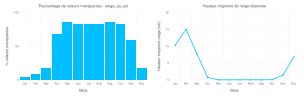

In [9]:
train.mois = month.(train.Date)

neige_by_mois = combine(
    groupby(train, :mois),
    :neige_au_sol => (x -> 100 * count(ismissing, x) / length(x)) => :pct_missing,
    :neige_au_sol => (x -> mean(skipmissing(x))) => :mean_neige
)
sort!(neige_by_mois, :mois)

mois_noms = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
neige_by_mois.mois_nom = mois_noms[neige_by_mois.mois]

p1 = Gadfly.plot(neige_by_mois, x=:mois_nom, y=:pct_missing, 
    Gadfly.Geom.bar,
    Gadfly.Guide.xlabel("Mois"),
    Gadfly.Guide.ylabel("% valeurs manquantes"),
    Gadfly.Guide.title("Pourcentage de valeurs manquantes - neige_au_sol"),
    Gadfly.Theme(bar_spacing=2pt),
    Gadfly.Coord.cartesian(ymin=0, ymax=100)
)

p2 = Gadfly.plot(neige_by_mois, x=:mois_nom, y=:mean_neige,
    Gadfly.Geom.line,
    Gadfly.Geom.point,
    Gadfly.Guide.xlabel("Mois"),
    Gadfly.Guide.ylabel("Hauteur moyenne neige (cm)"),
    Gadfly.Guide.title("Hauteur moyenne de neige observée"),
    Gadfly.Theme(line_width=2pt),
    Gadfly.Coord.cartesian(ymin=0, ymax=20)
)

Gadfly.draw(SVG(12inch, 4inch), Gadfly.hstack(p1, p2))

In [10]:
train.month = month.(train.Date)

missing_counts = combine(
    groupby(train, :month),
    :neige_au_sol => (x -> sum(ismissing, x)) => :n_missing,
    nrow => :total_rows
)

missing_counts.pct_missing = 100 .* missing_counts.n_missing ./ missing_counts.total_rows

sort!(missing_counts, :month)
missing_counts = missing_counts[missing_counts.n_missing .≥ 1, :]

total_manquants = sum(missing_counts.n_missing)

manquants_mai_octobre = sum(filter(row -> row.month in 5:10, missing_counts).n_missing)

pourcentage_cible = (manquants_mai_octobre / total_manquants) * 100

println("Parmi toutes les données manquantes, ", round(pourcentage_cible, digits=2), "% concernent la période de mai à octobre.\n")

select!(missing_counts, [:month, :pct_missing])
show(missing_counts, show_row_number=false)

Parmi toutes les données manquantes, 74.64% concernent la période de mai à octobre.

12×2 DataFrame
 month  pct_missing 
 Int64  Float64     
────────────────────
     1      4.32076
     2      7.97074
     3     17.6876
     4     67.4585
     5     85.4408
     6     82.5083
     7     82.3236
     8     82.4406
     9     85.6515
    10     83.2748
    11     58.9402
    12     17.7047

#### Variable ***PM*** 

Les données manquantes de la variable d'intérêt PM concernent 2.54% des données. Comme il y a un risque d'ajouter un biais dans nos prédicions en imputant des fausses valeurs pour la variable d'intérêt, nous choisirons de supprimer les données correspondantes. La cellule suivante montre que cela concerne 840 données.  

In [11]:
nb_manquantes_pm = count(ismissing, train.PM)

n = nrow(train)

pourcentage_pm = (nb_manquantes_pm / n) * 100

println("Nombre de données manquantes (PM) : $nb_manquantes_pm")
println("Pourcentage de données manquantes : ", round(pourcentage_pm, digits=2), " %")

Nombre de données manquantes (PM) : 840
Pourcentage de données manquantes : 2.54 %


#### Variables ***pluie***, ***neige***, ***precip_tot*** et ***03***.

Le pourcentage global des données manquantes des quatres variables restantes en prenant en compte la redondance est de 3.3% (voir cellule suivante). Nous choisirons d'imputer ces données par une méthode de forward / backward qui sera présentée dans la partie **Traitement des données manquantes**. 

In [12]:
variables = [:pluie, :neige, :precip_tot, :O3]

# On compte le nombre de lignes où il y a au moins une valeur 'missing' parmi les 4 colonnes
lignes_incompletes = count(row -> any(ismissing, row), eachrow(train[!, variables]))

pourcentage_impact = (lignes_incompletes / n) * 100

println("Nombre de lignes avec au moins une donnée manquante : $lignes_incompletes")
println("Pourcentage d'observations impactées : ", round(pourcentage_impact, digits=2), " %")

Nombre de lignes avec au moins une donnée manquante : 1096
Pourcentage d'observations impactées : 3.31 %


#### Conclusion pour l'analyse des données manquantes

Notre première analyse montre que les données manquantes de ce jeu de données sont la cause de contraintes matérielles ou de phénomènes climatiques. Nous avons donc adopté différents stratégies pour chaque variable :

* ***SO2*** - 45% des données : Le taux élevé s'explique par l'absence de capteurs sur 3 des 7 stations. L'information seraa conservée par en combinant une méthode d'interpolation temporelle pour les stations équipées et une imputation par la médiane journalière pour les autres.

* ***neige_au_sol*** - 8% des données : Les valeurs manquantes sont concentrée à 74% sur la période estivale. Nous imputerons des valeurs à pour cette variable : 0 cm de mai à septembre, et une interpolation temporelle pour le reste de l'année. 

* ***PM*** - 2.5% des données (variable d'intérêt) : Pour éviter d'introduire un biais dans l'entrainement, les lignes sans valeur de PM ont été supprimées.

* ***pluie***, ***neige***, ***precip_tot*** et ***O3*** - 3.3% des données : Interpolation temporelle..

En conclusion, nous choisissons de conserver un maximum de variables explicatives via une imputation adaptée, tout en garantissant l'intégrité de la variable à prédire.

In [13]:
# Cellule à supprimer manuellement (doublon de la cellule précédente)

### Distribution de la variable ***PM*** en fonction de la station

L'objectif de cette sous-section est de comprendre comment la variable ***PM*** se comporte en fonction des stations. 

Intuitivement, nous avons commencé par chercher une potentielle **corrélation entre les stations et le PM**. 
La cellule suivante permet de calculer pour toutes les années, la moyenne, la médiane et l'écart-type du PM de chaque station. On observe que les valeurs sont relativement proches pour toutes les stations, ce qui signifie que nous devons réaliser une analyse plus fine pour comprendre ce qui influence la valeur du PM autre que la station. 

In [14]:
safe_median(x) = (v = collect(skipmissing(x)); isempty(v) ? missing : median(v))
safe_std(x)    = (v = collect(skipmissing(x)); isempty(v) ? missing : std(v))

pm_by_station = combine(groupby(train, :nom), 
    :PM => (x -> mean(skipmissing(x))) => :PM_mean,
    :PM => safe_median => :PM_median,
    :PM => safe_std => :PM_std,
    nrow => :n_obs
)

dropmissing!(pm_by_station, :nom)

println(pm_by_station)

7×5 DataFrame
 Row │ nom                   PM_mean  PM_median  PM_std    n_obs 
     │ String31              Float64  Float64?   Float64?  Int64 
─────┼───────────────────────────────────────────────────────────
   1 │ Saint-Jean-Baptiste   20.8673       18.0   14.0009   6951
   2 │ Aéroport de Montréal  19.717        16.0   16.0497   6909
   3 │ Saint-Joseph          19.5865       16.0   13.8342   6265
   4 │ Caserne 17            20.9755       18.0   13.2641   4490
   5 │ York/Roberval         19.837        17.0   15.2714   3284
   6 │ Saint-Dominique       17.3666       14.0   15.3742   3260
   7 │ Anjou                 19.378        16.0   15.8863   1909


Dans la cellule suivante, nous affichons ces données sous une forme plus visuelle avec les boites à moustache des PM de toutes les stations. Ici, en choisissant ***ymax = 50***, nous zoomons pour voir les parties principales des distributions car nous analyserons les données extrêmes dans la cellule d'encore après.

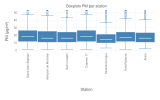

In [15]:
set_default_plot_size(16cm, 10cm)

pm_data = dropmissing(train, :PM)

p_boxplots = Gadfly.plot(pm_data, 
    x=:nom,
    y=:PM,
    Gadfly.Geom.boxplot,
    Gadfly.Theme(background_color=colorant"white", default_color=colorant"steelblue"),
    Gadfly.Guide.xlabel("Station"),
    Gadfly.Guide.ylabel("PM (μg/m³)"),
    Gadfly.Guide.title("Boxplots PM par station"),
    Gadfly.Coord.cartesian(ymin=0, ymax=50) 
)

display(p_boxplots)

### Analyse des valeurs extrêmes de ***PM***

Ensuite, nous nous sommes posé la question du traitement des valeurs extrêmes.
Nous avons utilisé le seuil de 80 μg/m³ communément à toutes les stations. Le choix de ce seuil est justifié par les cellules précédente, qui montrent que les valeurs de PM se concentrent majoritairement autour de leur moyenne qui est 20. 

Étant donné qu'elles représentent peu de données (0.42%, voir cellule suivante) nous choisirons de conserver les valeurs extrêmes du PM, car nous faisons la supposition qu'elles contiennent tout de même des informations pour la prédiction du PM.

In [16]:
train_valide = dropmissing(train, :PM)

outliers = filter(row -> row.PM > 80, train_valide)

total_lignes = nrow(train_valide)
nombre_outliers = nrow(outliers)

pct_global_outliers = (nombre_outliers / total_lignes) * 100

println("=== Bilan des valeurs extrêmes (PM > 80) ===")
println("Pourcentage global de valeurs extrêmes : ", round(pct_global_outliers, digits=2), "%")

=== Bilan des valeurs extrêmes (PM > 80) ===
Pourcentage global de valeurs extrêmes : 0.42%


De plus, ces valeurs extrêmes sont communes à toutes les stations, ce qui montre que ces valeurs ne sont surement pas des valeurs abbérantes à écarter du jeu de donnéee. La cellule suivante représente la distribution des données extrêmes PM par station avec le même seuil que précédemment.

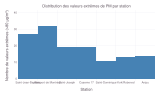

Station 3 (Saint-Jean-Baptiste ) : 0.4% de valeurs extrêmes.
Station 6 (Anjou) : 0.74% de valeurs extrêmes.
Station 17 (Caserne 17) : 0.43% de valeurs extrêmes.
Station 31 (Saint-Dominique) : 0.34% de valeurs extrêmes.
Station 66 (Aéroport de Montréal) : 0.47% de valeurs extrêmes.
Station 80 (Saint-Joseph) : 0.31% de valeurs extrêmes.
Station 103 (York/Roberval) : 0.42% de valeurs extrêmes.


In [17]:
outliers = filter(row -> row.PM > 80, dropmissing(train, :PM))

outliers_by_station = combine(groupby(outliers, [:stationId, :nom]), 
    nrow => :count_outliers
)

p_hist_outliers = Gadfly.plot(outliers_by_station, 
    x=:nom,
    y=:count_outliers,
    Gadfly.Geom.bar,
    Gadfly.Theme(background_color=colorant"white", default_color=colorant"steelblue"),
    Gadfly.Guide.xlabel("Station"),
    Gadfly.Guide.ylabel("Nombre de valeurs extrêmes (>80 μg/m³)"),
    Gadfly.Guide.title("Distribution des valeurs extrêmes de PM par station")
)

display(p_hist_outliers)

total_observations = combine(groupby(dropmissing(train, :PM), [:stationId, :nom]), nrow => :total_count)
outliers_percentage = leftjoin(outliers_by_station, total_observations, on=[:stationId, :nom])
outliers_percentage.pct_outliers = round.(outliers_percentage.count_outliers ./ outliers_percentage.total_count * 100, digits=2)

for row in eachrow(outliers_percentage)
    println("Station $(row.stationId) ($(row.nom)) : $(row.pct_outliers)% de valeurs extrêmes.")
end

Dans la cellule suivante, nous explorons la corrélation entre les années et le nombre de valeurs extrêmes. Notre but ici est de comprendre si certaines années sont exceptionnelles, pour pouvoir les répartir judicieusement dans nos ensembles d'entrainement et de validation. 


=== Distribution des valeurs extrêmes par année (ordre décroissant) ===
1. 2023: 35 valeurs extrêmes (moy: 182.0, max: 484)
2. 2013: 16 valeurs extrêmes (moy: 110.5, max: 124)
3. 2009: 15 valeurs extrêmes (moy: 140.1, max: 701)
4. 2020: 12 valeurs extrêmes (moy: 103.5, max: 147)
5. 2010: 11 valeurs extrêmes (moy: 124.4, max: 241)
6. 2024: 7 valeurs extrêmes (moy: 91.3, max: 112)
7. 2021: 6 valeurs extrêmes (moy: 105.5, max: 118)
8. 2008: 5 valeurs extrêmes (moy: 98.8, max: 126)
9. 2015: 4 valeurs extrêmes (moy: 93.2, max: 111)
10. 2016: 4 valeurs extrêmes (moy: 149.8, max: 296)
11. 2018: 4 valeurs extrêmes (moy: 208.5, max: 245)
12. 2022: 4 valeurs extrêmes (moy: 131.5, max: 225)
13. 2007: 3 valeurs extrêmes (moy: 90.7, max: 97)
14. 2012: 3 valeurs extrêmes (moy: 88.3, max: 100)
15. 2019: 3 valeurs extrêmes (moy: 91.3, max: 98)
16. 2011: 2 valeurs extrêmes (moy: 83.5, max: 84)
17. 2017: 1 valeurs extrêmes (moy: 82.0, max: 82)


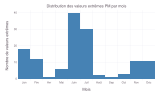

In [18]:
outliers = filter(row -> row.PM > 80, dropmissing(train, :PM))

outliers_temp = copy(outliers)
outliers_temp.mois = month.(outliers_temp.Date)

mois_noms = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
outliers_by_month = combine(groupby(outliers_temp, :mois), 
    nrow => :count_outliers,
    :PM => mean => :PM_mean,
    :PM => maximum => :PM_max
)

outliers_by_month.mois_nom = mois_noms[outliers_by_month.mois]

outliers_year = copy(outliers)
outliers_year.annee = year.(outliers_year.Date)

outliers_by_year = combine(groupby(outliers_year, :annee),
    nrow => :count_outliers,
    :PM => mean => :PM_mean,
    :PM => maximum => :PM_max
)

outliers_by_year_sorted = sort(outliers_by_year, :count_outliers, rev=true)

println("\n=== Distribution des valeurs extrêmes par année (ordre décroissant) ===")
for (i, row) in enumerate(eachrow(outliers_by_year_sorted))
    println("$(i). $(row.annee): $(row.count_outliers) valeurs extrêmes (moy: $(round(row.PM_mean, digits=1)), max: $(row.PM_max))")
end

p_month_outliers = Gadfly.plot(outliers_by_month, x=:mois_nom, y=:count_outliers,
    Gadfly.Geom.bar,
    Gadfly.Guide.xlabel("Mois"),
    Gadfly.Guide.ylabel("Nombre de valeurs extrêmes"),
    Gadfly.Guide.title("Distribution des valeurs extrêmes PM par mois"),
    Gadfly.Theme(background_color="white", default_color="steelblue")
)

display(p_month_outliers)

##### Conclusion sur l'analyse des valeurs extrêmes

En nous renseignant sur les évènements climatiques à Montréal, nous nous rendons compte que les données suspectes extrêmes sont dû à de réels évènements climatiques et non à des anomalies de capteurs. 

Par exemple, les 35 valeurs extrêmes de 2023 correspondent au 34 jours de smog liés aux feux de forêt [1] et les 16 valeurs extrêmes de 2013 correspondent aux 15 jours de smog [2].

Ces valeurs extrêmes sont conservées car nous estimons qu'elles portent de l'information prédictive sur le PM. À ce stade, nous pensons qu'il est judicieux de créer trois variables indicatrices : `is_outlier` pour les PM supérieurs à 80 μg/m³, `is_summer` pour les mois de juin à août, et `is_winter` pour décembre à février. 

Sources (rapports de la ville de Montréal): 
- [1] Feux forêts en 2023 : https://montreal.ca/articles/qualite-de-lair-montreal-bilan-2024-14887
- [2] 15 jours de smog à Montréal en 2013 : https://ville.montreal.qc.ca/pls/portal/docs/PAGE/ENVIRO_FR/MEDIA/DOCUMENTS/RSQA_bilan2013_FR.pdf

### Corrélations entre le ***PM*** et les autres polluants (***NO2***, ***O3*** et ***SO2***)

Dans cette partie de l'analyse, nous souhaitons regarder si les variables explicatives des autres polluants contiendrait des informations redondantes. Le but est ici de prévoir la multicolinéarité d'un modèle qui utiliserait ces trois variables. En effet, notre intuition nous dirait que ces trois variables sont très corrélées mais nous souhaitions le vérifier quantitativement.

Dans un premier temps, nous avons calculé la corrélation entre le ***PM*** et les trois autres polluants. Nous constatons que le ***NO2*** est la variable la plus corrélée au ***PM***, ce qui peut suggérer que nous garderons cette variable lors de la création de notre modèle.

In [19]:
data_poll = dropmissing(train, [:PM, :NO2, :O3])
data_poll = filter(row -> row.PM <= 80, data_poll)

stations_so2 = [6, 80, 3, 31]

data_so2 = filter(row -> !ismissing(row.stationId) && row.stationId in stations_so2, train)

data_so2 = dropmissing(data_so2, [:PM, :SO2])
data_so2 = filter(row -> row.PM <= 80, data_so2)

cor_no2 = cor(Float64.(data_poll.NO2), Float64.(data_poll.PM))
cor_o3  = cor(Float64.(data_poll.O3),  Float64.(data_poll.PM))
cor_so2 = cor(Float64.(data_so2.SO2),  Float64.(data_so2.PM))

println("Corrélation PM ~ NO2 : ", round(cor_no2, digits=3))
println("Corrélation PM ~ O3  : ", round(cor_o3,  digits=3))
println("Corrélation PM ~ SO2 (4 stations) : ", round(cor_so2, digits=3))

Corrélation PM ~ NO2 : 0.519
Corrélation PM ~ O3  : 0.017
Corrélation PM ~ SO2 (4 stations) : 0.065


Les corrélations sont toutes faibles, ce qui suggère l'absence de relation **linéaire** forte entre PM et ces polluants. Cela ne signifie pas l'absence de toute relation — une structure non-linéaire peut exister. Nous l'explorons visuellement ci-après.

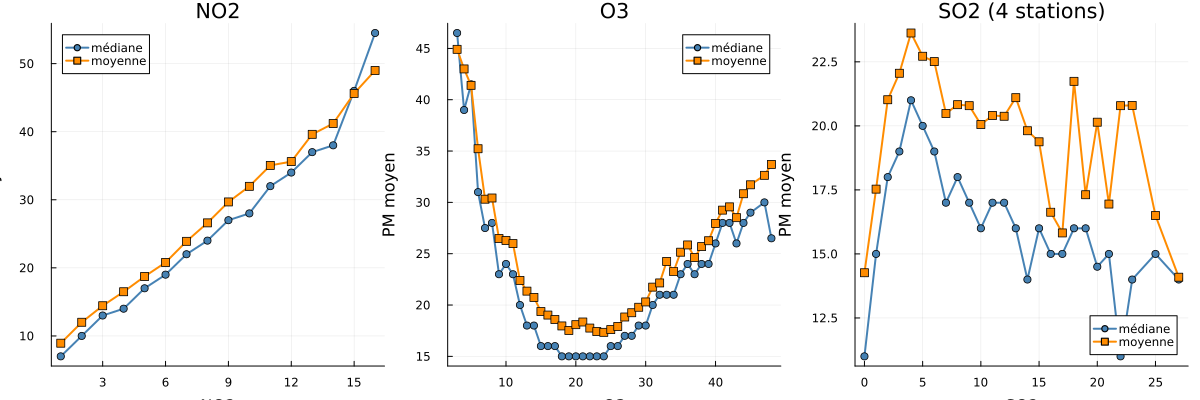

In [20]:
MIN_OBS = 10

# --- Agrégation PM par valeur discrète ---
function aggregate_pm(df::DataFrame, col::Symbol)
    res = combine(groupby(df, col),
        :PM => median => :mediane,
        :PM => mean   => :moyenne,
        nrow => :n
    )
    sort!(res, col)
    filter!(row -> row.n >= MIN_OBS, res)
    return res
end

pm_by_no2 = aggregate_pm(data_poll, :NO2)
pm_by_o3  = aggregate_pm(data_poll, :O3)
pm_by_so2 = aggregate_pm(data_so2,  :SO2)

# --- Plot NO2 ---
p_no2 = Plots.plot(pm_by_no2.NO2, pm_by_no2.mediane,
    label="médiane", marker=:circle, color=:steelblue,
    xlabel="NO2", ylabel="PM moyen", title="NO2",
    linewidth=2, grid=true
)
Plots.plot!(pm_by_no2.NO2, pm_by_no2.moyenne,
    label="moyenne", marker=:rect, color=:darkorange, linewidth=2
)

# --- Plot O3 ---
p_o3 = Plots.plot(pm_by_o3.O3, pm_by_o3.mediane,
    label="médiane", marker=:circle, color=:steelblue,
    xlabel="O3", ylabel="PM moyen", title="O3",
    linewidth=2, grid=true
)
Plots.plot!(pm_by_o3.O3, pm_by_o3.moyenne,
    label="moyenne", marker=:rect, color=:darkorange, linewidth=2
)

# --- Plot SO2 ---
p_so2 = Plots.plot(pm_by_so2.SO2, pm_by_so2.mediane,
    label="médiane", marker=:circle, color=:steelblue,
    xlabel="SO2", ylabel="PM moyen", title="SO2 (4 stations)",
    linewidth=2, grid=true
)
Plots.plot!(pm_by_so2.SO2, pm_by_so2.moyenne,
    label="moyenne", marker=:rect, color=:darkorange, linewidth=2
)

Plots.plot(p_no2, p_o3, p_so2, layout=(1,3), size=(1200, 400))

Le tableau suivant résume la nature de chaque polluant et la forme de sa relation au PM observée sur les graphiques précédents.

| Polluant | Relation au PM | Statut |
|----------|----------------|--------|
| **NO2** | Croissante quasi-linéaire | Retenu tel quel |
| **O3** | En U asymétrique | Retenu avec transformation |
| **SO2** | Signal faible et bruité | Exclu (4/7 stations seulement) |

Nous retenons donc **NO2** directement et **O3** moyennant une transformation pour capter sa non-linéarité ; **SO2** est écarté.

Pour exploiter ces relations dans un modèle linéaire, nous envisageons les transformations suivantes.

| Variable | Transformation | Justification |
|----------|----------------|---------------|
| **O3** | O3² ou abs(O3 − 20) | Capture la forme en U |
| **O3** | O3 × saison | La forme en U varie selon la période |
| **NO2** | log(NO2 + 1) | Atténue la queue droite |
| **NO2** | NO2 × O3 | Modélise les épisodes de pollution mixte |


Avant de les inclure tous dans un modèle, il est important de vérifier si NO2 et O3 apportent une information **complémentaire** ou si l'un est redondant avec l'autre. Des prédicteurs fortement corrélés entre eux (multicolinéarité) peuvent déstabiliser un modèle linéaire.

Corrélation NO2 ~ O3  : -0.041
Corrélation NO2 ~ SO2 : 0.104
Corrélation O3  ~ SO2 : 0.029


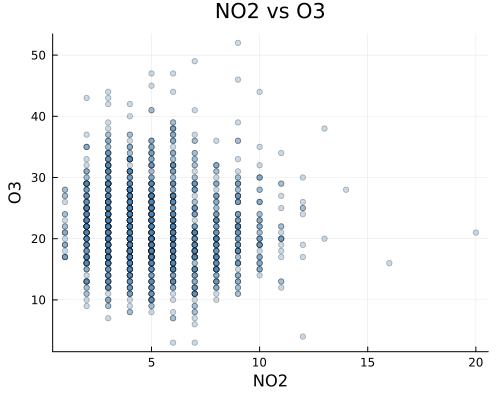

In [21]:
data_inter = dropmissing(train, [:NO2, :O3])

data_inter_so2 = dropmissing(filter(row -> !ismissing(row.stationId) && row.stationId in stations_so2, train), [:NO2, :O3, :SO2])

cor_no2_o3  = cor(Float64.(data_inter.NO2),      Float64.(data_inter.O3))
cor_no2_so2 = cor(Float64.(data_inter_so2.NO2),  Float64.(data_inter_so2.SO2))
cor_o3_so2  = cor(Float64.(data_inter_so2.O3),   Float64.(data_inter_so2.SO2))

println("Corrélation NO2 ~ O3  : ", round(cor_no2_o3,  digits=3))
println("Corrélation NO2 ~ SO2 : ", round(cor_no2_so2, digits=3))
println("Corrélation O3  ~ SO2 : ", round(cor_o3_so2,  digits=3))

idx = rand(1:nrow(data_inter), min(1500, nrow(data_inter)))
sample = data_inter[idx, :]

p_inter = Plots.scatter(sample.NO2, sample.O3,
    xlabel="NO2", ylabel="O3",
    title="NO2 vs O3",
    alpha=0.3, markersize=3, color=:steelblue,
    label=false, grid=true, size=(500, 400)
)

display(p_inter)

Pour confirmer cette intuition, nous calculons les corrélations croisées entre les trois polluants afin de vérifier l'absence de multicolinéarité.

| Paire | Corrélation | Lecture |
|-------|-------------|---------|
| NO2 ~ O3 | −0,041 | Indépendance quasi-totale |
| NO2 ~ SO2 | 0,104 | Très faible (sources différentes) |
| O3 ~ SO2 | 0,029 | Négligeable |

**NO2 et O3** apportent donc des informations complémentaires sans risque de multicolinéarité ; leur inclusion conjointe est justifiée. **SO2** reste exclu pour les raisons évoquées plus haut.

---
### Analyse des données météorologiques

#### Généralisation à l'île de Montréal

Les données météo proviennent uniquement de l'aéroport (YUL), mais doivent servir pour les 7 stations PM. Cette généralisation nous paraît raisonnable car l'île couvre une surface réduite (environ 50 × 20 km), les masses d'air y sont homogènes et les phénomènes qui nous intéressent (inversions thermiques, épisodes de smog) sont régionaux. Les variations locales seront absorbées par la variable `stationId`.

#### Variables candidates

Avant de passer aux chiffres, le tableau suivant liste les variables météo candidates et la raison pour laquelle on s'attend à ce qu'elles influencent le PM.

| Variable | Pourquoi elle compte |
|----------|----------------------|
| pluie | Lave les particules dans l'air |
| visibilite_moy | Indique directement l'air plus ou moins chargé |
| hum_rel_moy | Les particules grossissent avec l'humidité |
| temp_moy | Change la dispersion de l'air selon la saison |
| vitesse_vent_moy | Disperse les particules |

Ces hypothèses seront validées quantitativement dans la section suivante.

In [22]:
data_meteo = filter(row -> !ismissing(row.PM) && row.PM <= 80, train)

vars_meteo = [
    :pluie, :precip_tot, :neige, :neige_au_sol,
    :hum_rel_max, :hum_rel_min, :hum_rel_moy,
    :visibilite_max, :visibilite_min, :visibilite_moy,
    :temp_max, :temp_min, :temp_moy,
    :vitesse_vent_max, :vitesse_vent_min, :vitesse_vent_moy,
    :pression_max, :pression_min, :pression_moy,
    :pt_rosee
]

cors = []
for v in vars_meteo
    data_v = dropmissing(data_meteo[!, [:PM, v]], [:PM, v])
    if nrow(data_v) > 100
        c = cor(Float64.(data_v.PM), Float64.(data_v[!, v]))
        push!(cors, (variable=String(v), correlation=round(c, digits=3)))
    end
end

cor_df = DataFrame(cors)
sort!(cor_df, :correlation, rev=true)
println(cor_df)

20×2 DataFrame
 Row │ variable          correlation 
     │ String            Float64     
─────┼───────────────────────────────
   1 │ hum_rel_moy             0.208
   2 │ hum_rel_min             0.182
   3 │ hum_rel_max             0.166
   4 │ neige_au_sol            0.133
   5 │ pression_max            0.069
   6 │ pression_min            0.069
   7 │ pression_moy            0.064
   8 │ neige                   0.023
   9 │ precip_tot             -0.018
  10 │ pluie                  -0.025
  11 │ pt_rosee               -0.048
  12 │ temp_max               -0.079
  13 │ temp_moy               -0.097
  14 │ temp_min               -0.119
  15 │ visibilite_min         -0.208
  16 │ vitesse_vent_max       -0.223
  17 │ visibilite_max         -0.248
  18 │ vitesse_vent_min       -0.287
  19 │ visibilite_moy         -0.29
  20 │ vitesse_vent_moy       -0.298


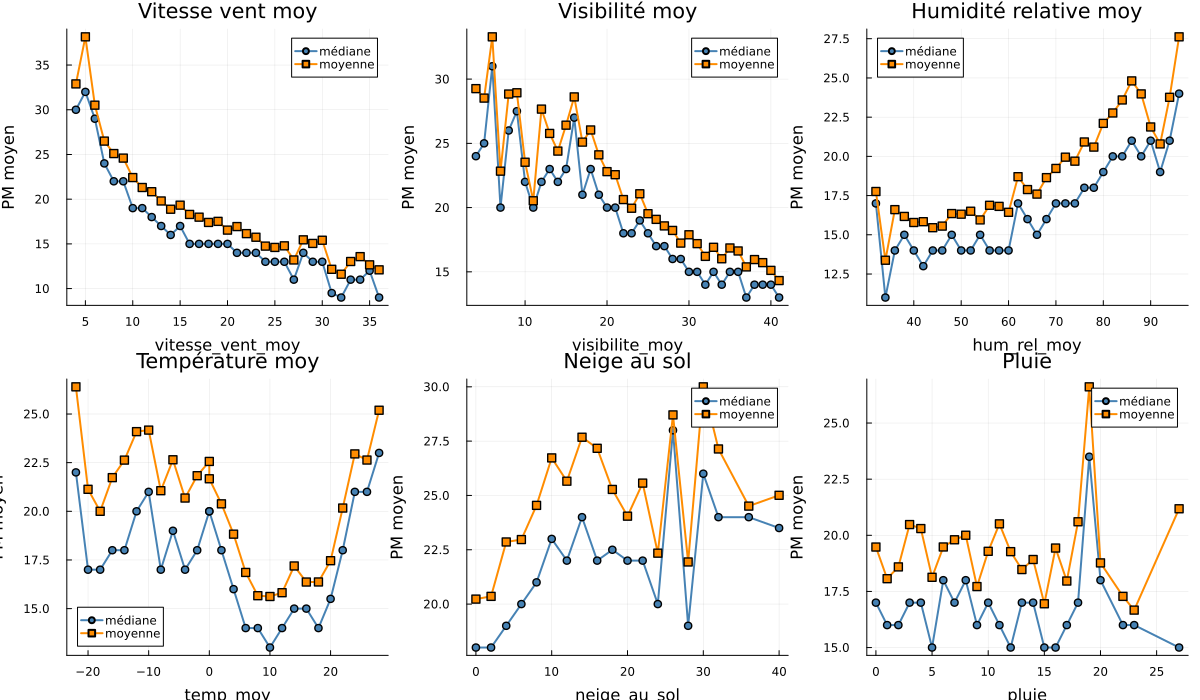

In [23]:
MIN_OBS = 50

function aggregate_pm_binned(df::DataFrame, col::Symbol, bin_width::Real)
    data_v = dropmissing(df[!, [:PM, col]], [:PM, col])
    data_v = filter(row -> row.PM <= 80, data_v)
    data_v[!, :bin] = round.(Float64.(data_v[!, col]) ./ bin_width) .* bin_width
    res = combine(groupby(data_v, :bin),
        :PM => median => :mediane,
        :PM => mean   => :moyenne,
        nrow => :n
    )
    sort!(res, :bin)
    filter!(row -> row.n >= MIN_OBS, res)
    return res
end

pm_vent  = aggregate_pm_binned(train, :vitesse_vent_moy, 1.0)
pm_visi  = aggregate_pm_binned(train, :visibilite_moy,   1.0)
pm_hum   = aggregate_pm_binned(train, :hum_rel_moy,      2.0)
pm_temp  = aggregate_pm_binned(train, :temp_moy,         2.0)
pm_neige = aggregate_pm_binned(train, :neige_au_sol,     2.0)
pm_pluie = aggregate_pm_binned(train, :pluie,            1.0)

function line_plot(df, titre, xlabel_str)
    Plots.plot(df.bin, df.mediane,
        label="médiane", marker=:circle, color=:steelblue,
        xlabel=xlabel_str, ylabel="PM moyen", title=titre,
        linewidth=2, grid=true
    )
    Plots.plot!(df.bin, df.moyenne,
        label="moyenne", marker=:rect, color=:darkorange, linewidth=2
    )
end

p1 = line_plot(pm_vent,  "Vitesse vent moy",     "vitesse_vent_moy")
p2 = line_plot(pm_visi,  "Visibilité moy",        "visibilite_moy")
p3 = line_plot(pm_hum,   "Humidité relative moy", "hum_rel_moy")
p4 = line_plot(pm_temp,  "Température moy",       "temp_moy")
p5 = line_plot(pm_neige, "Neige au sol",           "neige_au_sol")
p6 = line_plot(pm_pluie, "Pluie",                  "pluie")

Plots.plot(p1, p2, p3, p4, p5, p6, layout=(2,3), size=(1200, 700))

#### Relations PM ~ météo

Le tableau ci-dessous synthétise la forme de la relation entre le PM et chaque variable météo, telle qu'observée sur les graphiques précédents.

| Variable | Relation | Retenu ? |
|----------|----------|----------|
| Vent | non-linéaire (fort signal) | Oui |
| Visibilité | quasi-linéaire (fort signal) | Oui |
| Humidité | monotone | Oui |
| Température | Non-monotone (effet saison) | En interaction |
| Neige au sol | légère | Binaire (indicateur hiver) |
| Pluie | Signal plat | Non |

Nous conservons donc le vent, la visibilité, l'humidité et la neige ; la température n'est exploitée qu'en interaction et la pluie est écartée.

Pour chaque variable retenue, voici les transformations que nous envisageons de tester dans le modèle.

| Variable | Transformation | Pourquoi |
|----------|----------------|----------|
| Vent | log(vent + 1), ou 1 si vent faible (< 10) | L'effet du vent sature quand il devient fort |
| Visibilité | Telle quelle, ou 1 si visibilité basse (< 15) | Repérer les épisodes de mauvaise visibilité |
| Humidité | Telle quelle, ou multipliée par la température | Capter l'effet combiné chaleur + humidité |
| Température | Multipliée par la saison, ou 1 si très froid (< -10) | Distinguer hiver et été |
| Neige |  s'il y a de la neige au sol, 0 sinon | Marqueur simple de l'hiver |

Ces transformations seront comparées entre elles via le RMSE obtenu sur l'ensemble de validation.

---

### Interactions météorologiques

Les variables météo agissent rarement seules sur le PM. Le tableau suivant recense les combinaisons qui nous paraissent les plus pertinentes à tester.

| Interaction | Pourquoi | Effet attendu |
|-------------|----------|---------------|
| **Vent × Humidité** | Quand l'air est humide, les particules sont plus lourdes et le vent les disperse moins | Le vent a moins d'effet si l'humidité est élevée |
| **Vent × Visibilité** | Bon vent + bonne visibilité = air bien nettoyé | Les deux effets se renforcent |
| **Température × Humidité** | Chaleur + humidité accélèrent la formation de nouvelles particules | Plus de PM |
| **Pluie × Vent** | La pluie lave mieux quand le vent brasse l'air | Effet combiné plus fort |

Ces hypothèses sont ensuite validées chiffres à l'appui dans les cellules suivantes.

In [24]:
data_inter_meteo = dropmissing(train, [:PM, :vitesse_vent_moy, :hum_rel_moy, :visibilite_moy, :temp_moy, :pluie])
data_inter_meteo = filter(row -> !ismissing(row.PM) && row.PM < 500, data_inter_meteo)

inter_vent_hum  = data_inter_meteo.vitesse_vent_moy .* data_inter_meteo.hum_rel_moy
inter_vent_visi = data_inter_meteo.vitesse_vent_moy .* data_inter_meteo.visibilite_moy
inter_temp_hum  = data_inter_meteo.temp_moy         .* data_inter_meteo.hum_rel_moy
inter_pluie_vent= data_inter_meteo.pluie            .* data_inter_meteo.vitesse_vent_moy

pm_vals = Float64.(data_inter_meteo.PM)

println("=== Corrélations des termes d'interaction avec PM ===")
println("vent × humidité    : ", round(cor(inter_vent_hum,   pm_vals), digits=3))
println("vent × visibilité  : ", round(cor(inter_vent_visi,  pm_vals), digits=3))
println("temp × humidité    : ", round(cor(inter_temp_hum,   pm_vals), digits=3))
println("pluie × vent       : ", round(cor(inter_pluie_vent, pm_vals), digits=3))

println("\n=== Comparaison avec corrélations individuelles ===")
println("vent seul          : ", round(cor(Float64.(data_inter_meteo.vitesse_vent_moy), pm_vals), digits=3))
println("humidité seule     : ", round(cor(Float64.(data_inter_meteo.hum_rel_moy),      pm_vals), digits=3))
println("visibilité seule   : ", round(cor(Float64.(data_inter_meteo.visibilite_moy),   pm_vals), digits=3))
println("pluie seule        : ", round(cor(Float64.(data_inter_meteo.pluie),            pm_vals), digits=3))

=== Corrélations des termes d'interaction avec PM ===
vent × humidité    : -0.17
vent × visibilité  : -0.356
temp × humidité    : -0.063
pluie × vent       : -0.048

=== Comparaison avec corrélations individuelles ===
vent seul          : -0.255
humidité seule     : 0.162
visibilité seule   : -0.266
pluie seule        : -0.028


In [25]:
# Nouvelles interactions à tester

inter_vent2       = data_inter_meteo.vitesse_vent_moy .^ 2
inter_visi_hum    = data_inter_meteo.visibilite_moy   .* data_inter_meteo.hum_rel_moy
inter_vent_temp   = data_inter_meteo.vitesse_vent_moy .* data_inter_meteo.temp_moy
inter_visi_temp   = data_inter_meteo.visibilite_moy   .* data_inter_meteo.temp_moy
inter_hum_visi    = data_inter_meteo.hum_rel_moy      .* data_inter_meteo.visibilite_moy
inter_vent_visi_hum = data_inter_meteo.vitesse_vent_moy .* data_inter_meteo.visibilite_moy .* data_inter_meteo.hum_rel_moy
log_vent          = log.(data_inter_meteo.vitesse_vent_moy .+ 1)
log_vent_visi     = log.(data_inter_meteo.vitesse_vent_moy .+ 1) .* data_inter_meteo.visibilite_moy

println("vent²                    : ", round(cor(inter_vent2,         pm_vals), digits=3))
println("visibilité × humidité    : ", round(cor(inter_visi_hum,      pm_vals), digits=3))
println("vent × temp              : ", round(cor(inter_vent_temp,     pm_vals), digits=3))
println("visibilité × temp        : ", round(cor(inter_visi_temp,     pm_vals), digits=3))
println("vent × visibilité × hum  : ", round(cor(inter_vent_visi_hum, pm_vals), digits=3))
println("log(vent+1)              : ", round(cor(log_vent,            pm_vals), digits=3))
println("log(vent+1) × visibilité : ", round(cor(log_vent_visi,       pm_vals), digits=3))

vent²                    : -0.223
visibilité × humidité    : -0.229
vent × temp              : -0.072
visibilité × temp        : -0.101
vent × visibilité × hum  : -0.341
log(vent+1)              : -0.276
log(vent+1) × visibilité : -0.358


#### Synergie vent × visibilité

Nous voulons vérifier si combiner le vent et la visibilité apporte plus d'information que chacun pris séparément. Le tableau ci-dessous donne la corrélation au PM pour chaque cas.

| Variable | Corrélation |
|----------|-------------|
| vent × visibilité | **-0,356** |
| log(vent+1) × visibilité | **-0,358** |
| vent seul | -0,298 |
| visibilité seule | -0,290 |

La combinaison est plus corrélée au PM que chaque variable prise isolément, ce qui confirme que le vent et la visibilité agissent ensemble pour mieux expliquer la pollution. Ajouter l'humidité à cette combinaison n'améliore pas le signal, car elle capte un autre effet.

Nous retiendrons donc la combinaison vent × visibilité, en plus du vent, de la visibilité et de l'humidité pris individuellement.

### Dynamique saisonnière du PM

Le double-pic hiver/été persiste même sans outliers, ce qui confirme un phénomène régional touchant les 7 stations. Le tableau suivant résume les valeurs moyennes observées et les mécanismes qui les expliquent.

| Saison | PM moyen | Drivers |
|--------|----------|---------|
| Hiver (jan-fév) | ~20-28 | Chauffage, inversions thermiques |
| Printemps/Automne | ~12-18 | Périodes de respiration |
| Été (juin-juil) | ~22-29 | Chaleur, ozone, feux de forêt |

Pour modéliser ces régimes, nous retiendrons la saison calculée, le mois pour plus de granularité, les températures moyennes et minimales comme proxy des inversions, et la hauteur de neige au sol comme indicateur hivernal. Nous faisons l'hypothèse que la météo de l'aéroport reste représentative de l'île, son climat étant homogène sur environ 15 km, même si le vent et la visibilité peuvent varier localement.

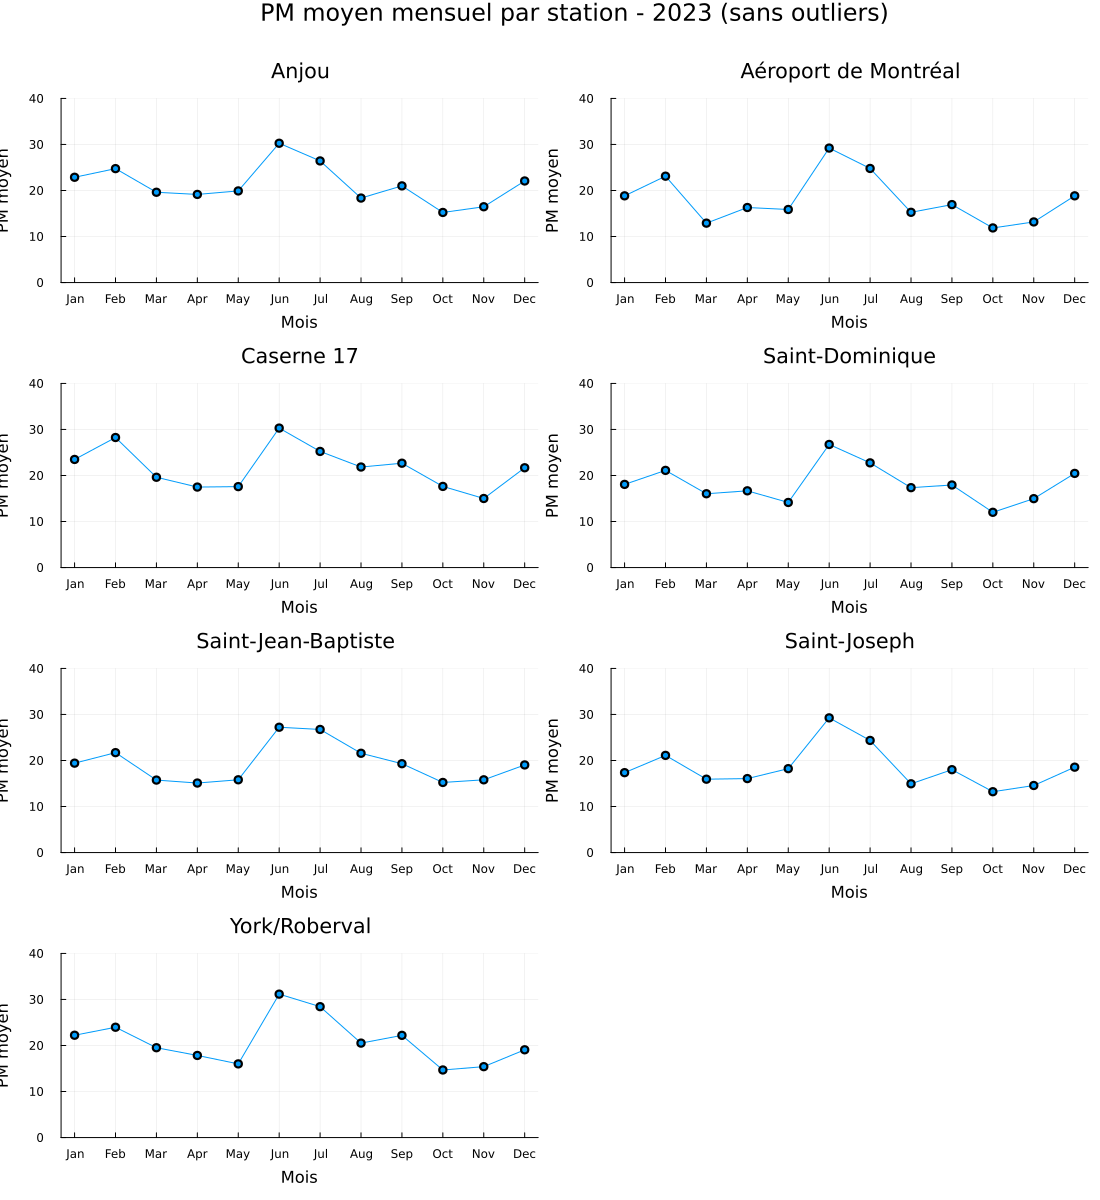

In [26]:
if !("annee" in names(train))
    train.annee = year.(train.Date)
end
if !("mois" in names(train))
    train.mois = month.(train.Date)
end

train_2023_clean = filter(row -> row.annee == 2023 && row.PM <= 100, dropmissing(train, :PM))

pm_station_month_clean = combine(
    groupby(train_2023_clean, [:nom, :mois]),
    :PM => mean => :PM_mean
)
sort!(pm_station_month_clean, [:nom, :mois])

mois_vals   = 1:12
mois_labels = Dates.monthabbr.(Date.(2023, mois_vals, 1))

stations   = sort(unique(pm_station_month_clean.nom))
plots_list = Plots.Plot[]

for station in stations
    df_station = filter(:nom => ==(station), pm_station_month_clean)
    sort!(df_station, :mois)

    p = Plots.plot(
        df_station.mois, df_station.PM_mean,
        seriestype = :line,
        marker    = :circle,
        xticks    = (mois_vals, mois_labels),
        title     = string(station),
        xlabel    = "Mois",
        ylabel    = "PM moyen",
        legend    = false,
        ylims     = (0, 40)
    )
    push!(plots_list, p)
end

Plots.plot(plots_list..., layout=(4, 2), size=(1100, 1200), 
    plot_title="PM moyen mensuel par station - 2023 (sans outliers)")

### PM mensuel par station (2023)

Le profil de 2023 révèle un lien clair entre chaleur estivale et pollution. Les PM montent en mai-juin, synchronisés avec les feux de forêt documentés. Cette hausse régionale sur toutes les stations évoque des panaches de fumée plutôt qu'une source locale. L'automne et l'hiver restent stables, avec une légère remontée hivernale liée au chauffage. Pour isoler la dynamique normale, nous réexaminons les données en excluant les outliers (PM > 80 μg/m³).

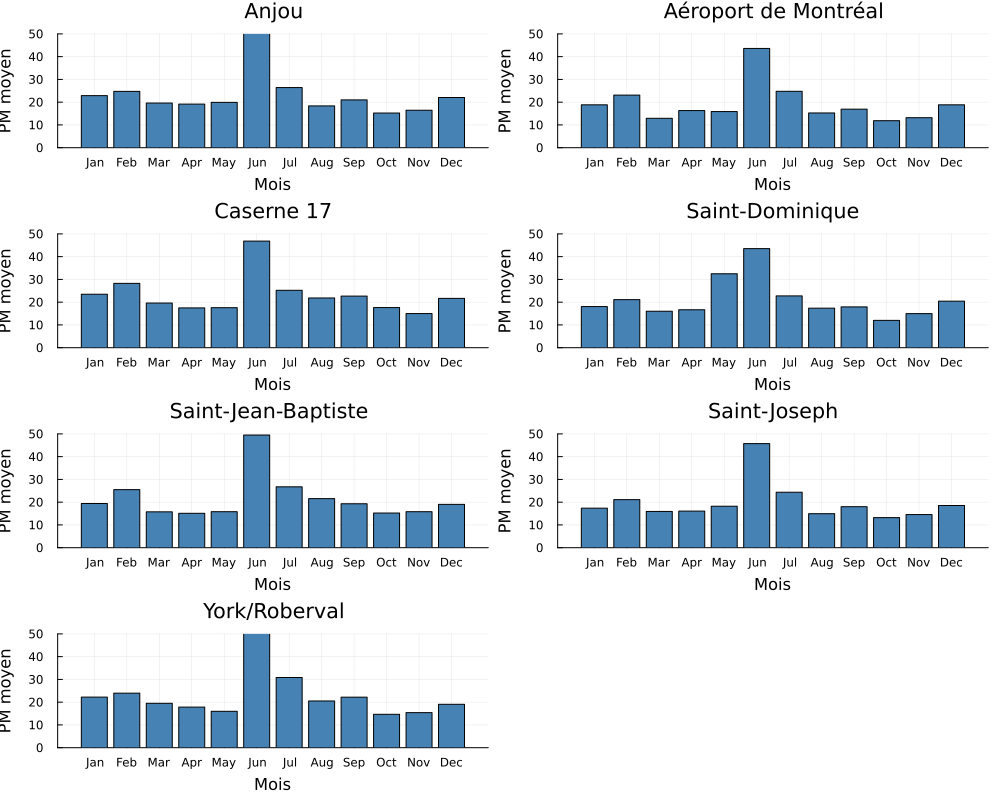

In [27]:
if !("annee" in names(train))
    train.annee = year.(train.Date)
end
if !("mois" in names(train))
    train.mois = month.(train.Date)
end
 
train_2023 = filter(:annee => ==(2023), dropmissing(train, :PM))
 
pm_station_month = combine(
    groupby(train_2023, [:nom, :mois]),
    :PM => mean => :PM_mean
)
sort!(pm_station_month, [:nom, :mois])
 
mois_vals   = 1:12
mois_labels = Dates.monthabbr.(Date.(2023, mois_vals, 1))
 
stations   = sort(unique(pm_station_month.nom))
plots_list = Plots.Plot[]
 
for station in stations
    df_station = filter(:nom => ==(station), pm_station_month)
    sort!(df_station, :mois)
    p = Plots.bar(df_station.mois, df_station.PM_mean,
        title=station, xlabel="Mois", ylabel="PM moyen",
        xticks=(mois_vals, mois_labels), label=false,
        color=:steelblue, ylims=(0, 50)
    )
    push!(plots_list, p)
end
 
Plots.plot(plots_list..., layout=(4, 2), size=(1000, 800))

In [28]:

println("Avant nettoyage : ", nrow(train), " lignes")
println("Valeurs PM ≥ 500 : ", sum(skipmissing(train.PM .>= 500)))

train = filter(row -> ismissing(row.PM) || row.PM < 500, train)

println("Après nettoyage : ", nrow(train), " lignes")
println("PM maximum après nettoyage : ", maximum(skipmissing(train.PM)))

Avant nettoyage : 33069 lignes
Valeurs PM ≥ 500 : 1
Après nettoyage : 33068 lignes
PM maximum après nettoyage : 484


### Features temporelles — mémoire atmosphérique

Les PM s'accumulent progressivement pendant les épisodes de mauvaise dispersion, ce qui suggère de construire des features qui capturent cette inertie. Nous en retenons trois familles, résumées dans le tableau suivant.

| Famille | Description | Variables |
|---------|-------------|-----------|
| Lags | Valeurs J-1, J-2 | PM_lag1, NO2_lag1, O3_lag1 |
| Moyennes glissantes | Tendance 3-7 jours | PM_roll3, NO2_roll3, temp_roll3 |
| Cumul pluviométrique | Jours sans pluie consécutifs | jours_sans_pluie |

Nous vérifions ensuite quantitativement laquelle de ces features apporte le plus d'information sur le PM.

In [29]:

train_sorted = sort(train, [:stationId, :Date])
train_sorted = filter(row -> !ismissing(row.PM), train_sorted)

function create_temporal_features(df::DataFrame)
    df = sort(df, :Date)
    n = nrow(df)

    # Lags PM
    df.PM_lag1 = vcat([missing], df.PM[1:end-1])
    df.PM_lag2 = vcat([missing, missing], df.PM[1:end-2])

    df.NO2_lag1 = vcat([missing], coalesce.(df.NO2[1:end-1], missing))
    df.O3_lag1  = vcat([missing], coalesce.(df.O3[1:end-1],  missing))

    pm_roll3 = Vector{Union{Missing,Float64}}(missing, n)
    pm_roll7 = Vector{Union{Missing,Float64}}(missing, n)
    for i in 1:n
        if i >= 3
            vals3 = collect(skipmissing(df.PM[max(1,i-2):i]))
            pm_roll3[i] = length(vals3) >= 2 ? mean(vals3) : missing
        end
        if i >= 7
            vals7 = collect(skipmissing(df.PM[max(1,i-6):i]))
            pm_roll7[i] = length(vals7) >= 4 ? mean(vals7) : missing
        end
    end
    df.PM_roll3 = pm_roll3
    df.PM_roll7 = pm_roll7

    dry_days = Vector{Int}(undef, n)
    for i in 1:n
        if i == 1 || ismissing(df.pluie[i-1])
            dry_days[i] = 0
        elseif coalesce(df.pluie[i], 0.0) > 0
            dry_days[i] = 0
        else
            dry_days[i] = dry_days[i-1] + 1
        end
    end
    df.jours_sans_pluie = dry_days

    return df
end

train_temporal_feat = combine(groupby(train_sorted, :stationId)) do sdf
    create_temporal_features(copy(sdf))
end

feats_temp = [:PM_lag1, :PM_lag2, :NO2_lag1, :O3_lag1, :PM_roll3, :PM_roll7, :jours_sans_pluie]

println("=== Corrélations features temporelles ~ PM ===")
for f in feats_temp
    data_f = dropmissing(train_temporal_feat[!, [:PM, f]])
    if nrow(data_f) > 100
        c = cor(Float64.(data_f.PM), Float64.(data_f[!, f]))
        println("$f : ", round(c, digits=3))
    end
end

=== Corrélations features temporelles ~ PM ===
PM_lag1 : 0.495
PM_lag2 : 0.197
NO2_lag1 : 0.344
O3_lag1 : 0.025
PM_roll3 : 0.73
PM_roll7 : 0.542
jours_sans_pluie : 0.159


#### Corrélations des variables temporelles avec le PM

Le tableau ci-dessous donne la corrélation entre chaque variable temporelle et la valeur du PM du jour.

| Variable | Corrélation | Ce que ça veut dire |
|----------|-------------|----------------------|
| PM_roll3 | **+0,730** | Moyenne des 3 derniers jours — la plus forte de toute l'analyse |
| PM_roll7 | **+0,542** | Moyenne sur 7 jours — utile pour les longs épisodes |
| PM_lag1 | **+0,495** | PM de la veille — forte persistance d'un jour à l'autre |
| NO2_lag1 | **+0,344** | NO2 de la veille — sources communes (trafic, combustion) |
| PM_lag2 | **+0,197** | PM d'il y a 2 jours — le signal s'atténue vite |
| jours_sans_pluie | **+0,159** | Accumulation quand il ne pleut pas |
| O3_lag1 | **+0,025** | Quasi nul — l'O3 n'a pas de mémoire |

La moyenne des 3 derniers jours (PM_roll3) est plus corrélée au PM que toutes les variables météo et tous les autres polluants testés jusqu'ici. Autrement dit, le meilleur moyen de prédire le PM aujourd'hui est de regarder le niveau moyen des trois jours précédents.

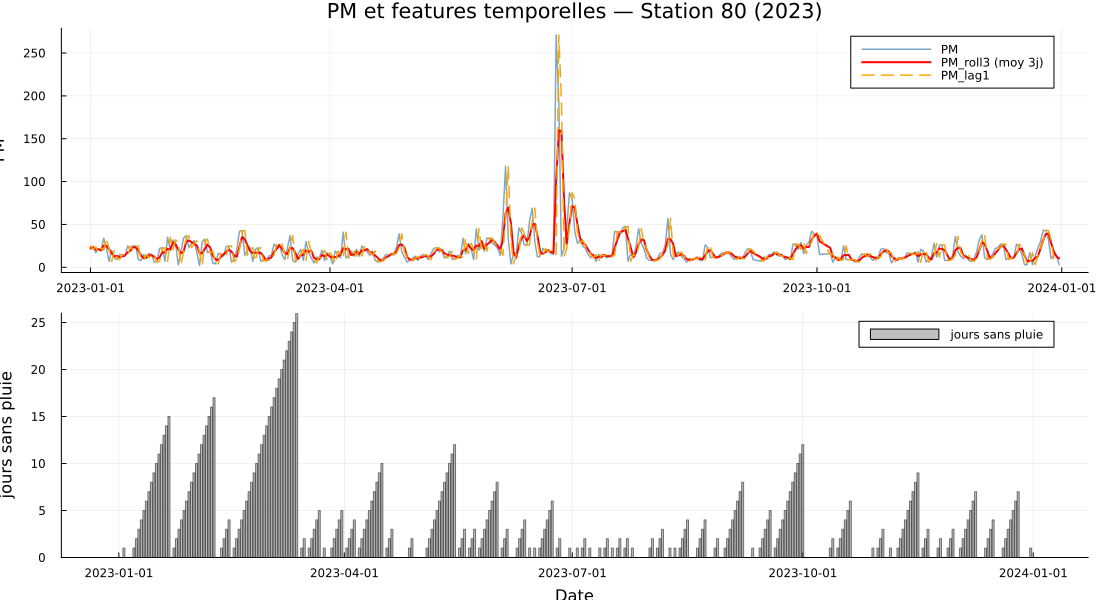

In [30]:

station_viz = filter(row -> row.stationId == 80, train_temporal_feat)
sort!(station_viz, :Date)

function get_saison(m::Int)
    m in [12, 1, 2]  && return "Hiver"
    m in [3, 4, 5]   && return "Printemps"
    m in [6, 7, 8]   && return "Été"
    return "Automne"
end
station_viz.saison = get_saison.(month.(station_viz.Date))

# --- Visualisation sur 2023 (année avec le plus de pics) ---
viz_2023 = filter(row -> year(row.Date) == 2023, station_viz)
viz_2023 = dropmissing(viz_2023, [:PM, :PM_roll3, :PM_lag1, :jours_sans_pluie])

p_ts = Plots.plot(viz_2023.Date, viz_2023.PM,
    label="PM", color=:steelblue, linewidth=1.5,
    alpha=0.7, ylabel="PM", title="PM et features temporelles — Station 80 (2023)",
    legend=:topright, grid=true
)
Plots.plot!(viz_2023.Date, viz_2023.PM_roll3,
    label="PM_roll3 (moy 3j)", color=:red, linewidth=2
)
Plots.plot!(viz_2023.Date, viz_2023.PM_lag1,
    label="PM_lag1", color=:orange, linewidth=1.5, linestyle=:dash
)

# Jours sans pluie sur axe secondaire
p_dry = Plots.bar(viz_2023.Date, viz_2023.jours_sans_pluie,
    label="jours sans pluie", color=:gray, alpha=0.5,
    ylabel="jours sans pluie", xlabel="Date", grid=true
)

Plots.plot(p_ts, p_dry, layout=(2,1), size=(1100, 600))

#### Comportement temporel (Station 80, 2023)

Sur la station 80 en 2023, la moyenne des 3 derniers jours (PM_roll3) et le PM de la veille (PM_lag1) suivent le PM de très près (corrélations de 0,73 et 0,50). Le tableau suivant illustre leur comportement sur deux épisodes marquants de l'année.

| Épisode | Ce qu'on observe | Rôle des variables temporelles |
|---------|------------------|--------------------------------|
| Juin 2023 (feux de forêt) | Pic très élevé (~250), 2-3 jours | PM_roll3 commence à monter avant le pic : signal d'alerte |
| Mars-avril | 25 jours sans pluie, PM élevé en continu | Accumulation locale par manque de pluie |

La variable jours_sans_pluie explique bien l'accumulation locale, mais pas les épisodes venus de loin comme les feux de forêt. En pratique, nous utiliserons surtout PM_roll3 et PM_lag1, et nous garderons jours_sans_pluie en complément pour les périodes normales.



## Synthèse de l'analyse exploratoire

L'analyse exploratoire nous a permis de repérer les variables les plus utiles pour prédire le PM.

La variable la plus corrélée au PM est sa propre moyenne sur les trois derniers jours (**PM_roll3**), avec une corrélation de 0,73. Cela montre que le PM a tendance à s'accumuler sur plusieurs jours quand les conditions ne permettent pas bien de disperser l'air.

La météo joue aussi un rôle important. Le vent et la visibilité sont les deux variables les plus informatives, et les combiner donne encore plus d'information que chacune prise seule. L'humidité apporte un signal complémentaire, plus modéré.

Parmi les autres polluants, le NO2 est utile, surtout via sa moyenne sur trois jours. Le O3 ne suit pas une relation simple avec le PM, mais plutôt une forme en U que l'on pourra capter avec une transformation. Le SO2 est écarté car il est absent sur plusieurs stations.

Enfin, on voit un effet de saison clair : l'hiver et l'été correspondent à deux comportements différents du PM, que nous prendrons en compte dans le modèle.

Le modèle s'appuiera donc surtout sur PM_roll3 et quelques valeurs des jours précédents, sur le vent, la visibilité et l'humidité, sur les transformations du O3 et du vent, et sur la saison.

---
# Préparation des données

Nous construisons des variables dérivées selon quatre idées issues de l'analyse exploratoire :

- **Persistance** : PM et NO2 moyennés sur les derniers jours et la veille.
- **Saisonnalité** : sinus/cosinus du mois et interactions avec la température ; O3 au carré pour capter la relation en U.
- **Dispersion et pluie** : vent × visibilité, jours consécutifs sans pluie, sécheresse sur 14 jours.
- **Régimes particuliers** : feux en été et inversions hivernales.

| Groupe | Variables |
|--------|-----------|
| Mémoire PM et NO2 | PM_lag1, PM_roll3, PM_roll7, NO2_lag1, NO2_roll3 |
| Saisonnalité | mois_sin, mois_cos, temp_x_mois_sin, temp_x_mois_cos |
| Températures | temp_min_roll3, temp_max_roll7 |
| Ozone | O3_sq (relation en U) |
| Dispersion | vent_x_visibilite, visibilite_min_roll3, vent_min_roll3 |
| Précipitations | jours_sans_pluie, pluie_cum14, deficit_pluie14 |
| Régime feux (mai–sept) | is_fire_season, fire_tmax_inter, fire_vis_inter |
| Régime hiver (déc–fév) | is_winter, winter_tmin_inter, winter_vent_inter |

Avant de générer les variables, nous préparons la structure du jeu de données en retirant les observations incomplètes et en extrayant les unités de temps nécessaires.

* **Filtrage des stations** : Suppression des lignes ne possédant pas d'identifiant de station pour garantir l'intégrité de la segmentation par localisation.
* **Indexation temporelle** : Extraction du mois à partir de la date afin de servir de base aux calculs des tendances périodiques.

In [31]:
train = filter(row -> !ismissing(row.stationId), train)

Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy,mois,month,annee
,Int64?,String31?,Float64?,Float64?,Int64?,Date,Int64?,Int64?,Int64?,Int64?,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Float64?,Float64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Int64,Int64
1,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-01,33,19,7,11,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775,1,1,2007
2,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-01,9,18,6,missing,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775,1,1,2007
3,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-02,14,22,7,11,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167,1,1,2007
4,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-02,5,22,5,missing,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167,1,1,2007
5,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-03,25,11,7,13,0.0,0.0,0.0,0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833,1,1,2007
6,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-03,12,16,6,missing,0.0,0.0,0.0,0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833,1,1,2007
7,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-04,25,9,8,15,0.6,0.0,0.6,0,80,58,69.5833,0.375,22,0,13.5,48.3,24.1,26.6792,101.09,100.55,100.906,9.6,1.4,5.55,1,1,2007
8,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-04,21,12,9,missing,0.6,0.0,0.6,0,80,58,69.5833,0.375,22,0,13.5,48.3,24.1,26.6792,101.09,100.55,100.906,9.6,1.4,5.55,1,1,2007
9,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-05,23,7,7,9,14.2,0.0,14.2,0,100,75,96.4167,6.625,17,4,10.7917,25.0,1.2,7.66667,100.57,100.09,100.314,9.7,4.6,7.17917,1,1,2007


In [32]:
train.mois = month.(train.Date);

Nous définissons d'abord des fonctions utilitaires pour calculer les décalages, les moyennes mobiles et l'accumulation de jours secs. Ces outils nous permettent d'automatiser la création des caractéristiques identifiées lors de l'analyse exploratoire.

In [33]:
function lag_vec(v::AbstractVector, n::Int=1)
    T = Union{eltype(v), Missing}
    out = Vector{T}(missing, length(v))
    out[n+1:end] = v[1:end-n]
    out
end

function roll_mean(v::AbstractVector, n::Int)
    out = Vector{Union{Float64, Missing}}(missing, length(v))
    for i in n:length(v)
        vals = collect(skipmissing(v[max(1, i-n+1):i]))
        out[i] = isempty(vals) ? missing : mean(vals)
    end
    out
end

function roll_sum(v::AbstractVector, n::Int, minn::Int)
    out = Vector{Union{Float64, Missing}}(missing, length(v))
    for i in n:length(v)
        vals = collect(skipmissing(v[max(1, i-n+1):i]))
        length(vals) >= minn && (out[i] = sum(vals))
    end
    out
end

function jours_sans_pluie_vec(v::AbstractVector)
    out = Vector{Int}(undef, length(v))
    count = 0
    for i in eachindex(v)
        p = coalesce(v[i], 0.0)
        count = p > 0 ? 0 : count + 1
        out[i] = count
    end
    out
end

sort!(train, [:stationId, :Date])

transform!(groupby(train, :stationId),
    :PM  => (x -> lag_vec(x, 1))   => :PM_lag1,
    :PM  => (x -> roll_mean(x, 3)) => :PM_roll3,
    :PM  => (x -> roll_mean(x, 7)) => :PM_roll7,
    :NO2 => (x -> lag_vec(x, 1))   => :NO2_lag1,
    :NO2 => (x -> roll_mean(x, 3)) => :NO2_roll3,
    :pluie => jours_sans_pluie_vec => :jours_sans_pluie,
    :pluie => (x -> roll_sum(x, 14, 7)) => :pluie_cum14)

train.mois_sin        = sin.(2π .* train.mois ./ 12)
train.mois_cos        = cos.(2π .* train.mois ./ 12)
train.temp_x_mois_sin = train.temp_moy .* train.mois_sin
train.temp_x_mois_cos = train.temp_moy .* train.mois_cos

train.O3_sq = coalesce.(train.O3, 0.0) .^ 2

train.vent_x_visibilite = train.vitesse_vent_moy .* train.visibilite_moy

transform!(groupby(train, :stationId),
    :temp_max         => (x -> roll_mean(x, 7)) => :temp_max_roll7,
    :temp_min         => (x -> roll_mean(x, 3)) => :temp_min_roll3,
    :vitesse_vent_min => (x -> roll_mean(x, 3)) => :vent_min_roll3,
    :visibilite_min   => (x -> roll_mean(x, 3)) => :visibilite_min_roll3)

train.is_fire_season = in.(train.mois, Ref([5, 6, 7, 8, 9]))
train.is_winter      = in.(train.mois, Ref([12, 1, 2]))

for col in [:temp_max_roll7, :temp_min_roll3, :vent_min_roll3, :visibilite_min_roll3]
    med = median(skipmissing(train[:, col]))
    train[!, col] = Float64.(coalesce.(train[:, col], med))
end

Q25_PLUIE14           = quantile(collect(skipmissing(train.pluie_cum14)), 0.25)
train.deficit_pluie14 = Int.(coalesce.(train.pluie_cum14 .< Q25_PLUIE14, false))

train.fire_tmax_inter   = ifelse.(train.is_fire_season, train.temp_max_roll7,       0.0)
train.winter_tmin_inter = ifelse.(train.is_winter,      train.temp_min_roll3,       0.0)
train.winter_vent_inter = ifelse.(train.is_winter,      train.vent_min_roll3,       0.0)
train.fire_vis_inter    = ifelse.(train.is_fire_season, train.visibilite_min_roll3, 0.0)

println("Création des variables explicatives terminée — $(ncol(train)) colonnes dans train")

Création des variables explicatives terminée — 57 colonnes dans train


Ici, certaines variables ont été créées mais ne seront pas utilisées dans le modèle final.

---
# Traitement des données manquantes

En premier lieu, nous retirons l'observation du 31 décembre 2024 identifiée lors de l'analyse exploratoire. Cette donnée est jugée inexploitable en raison de l'absence d'identifiant de station et d'un trop grand nombre de valeurs manquantes.

In [34]:
train = dropmissing(train, :nom)
last(train, 1)

Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy,mois,month,annee,PM_lag1,PM_roll3,PM_roll7,NO2_lag1,NO2_roll3,jours_sans_pluie,pluie_cum14,mois_sin,mois_cos,temp_x_mois_sin,temp_x_mois_cos,O3_sq,vent_x_visibilite,temp_max_roll7,temp_min_roll3,vent_min_roll3,visibilite_min_roll3,is_fire_season,is_winter,deficit_pluie14,fire_tmax_inter,winter_tmin_inter,winter_vent_inter,fire_vis_inter
,Int64?,String31,Float64?,Float64?,Int64?,Date,Int64?,Int64?,Int64?,Int64?,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Float64?,Float64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Int64,Int64,Int64?,Float64?,Float64?,Int64?,Float64?,Int64,Float64?,Float64,Float64,Float64,Float64,Real,Float64,Float64,Float64,Float64,Float64,Bool,Bool,Int64,Float64,Float64,Float64,Float64
1,103,York/Roberval,45.4646,-73.5826,25,2024-12-30,23,missing,6,missing,5.6,0.0,5.6,missing,97,69,84.875,5.09583,39,0,21.75,48.3,4.8,23.1042,99.8,99.09,99.3596,11.1,2.8,7.52083,12,12,2024,75,50.0,47.8571,6,6.0,0,19.8,-2.44929e-16,1.0,-1.84207e-15,7.52083,0.0,502.516,-2.57143,-3.06667,4.33333,2.33333,false,true,0,0.0,-3.06667,4.33333,0.0


#### Traitement de la variable neige_au_sol

Pour traiter la variable `neige_au_sol`, nous utilisons une approche en deux étapes :

* **Logique saisonnière** : Nous imposons une valeur de 0 cm pour la période de mai à septembre inclusivement.
* **Interpolation** : Pour les données manquantes durant la période hivernale, nous appliquons une interpolation linéaire pondérée par la distance temporelle entre les mesures connues.

Nous estimons que la perte de précision causé par cette méthode est négligeable.

In [35]:
function interpolate(v)
    v_int = copy(v)
    n = length(v_int)

    fwd_val = similar(v_int)
    fwd_dist = zeros(Int, n)

    last_val = missing
    dist = 0
    for i in 1:n
        if !ismissing(v_int[i])
            last_val = v_int[i]
            dist = 0
        else
            dist += 1
        end
        fwd_val[i] = last_val
        fwd_dist[i] = dist
    end

    bwd_val = similar(v_int)
    bwd_dist = zeros(Int, n)

    last_val = missing
    dist = 0
    for i in n:-1:1
        if !ismissing(v_int[i])
            last_val = v_int[i]
            dist = 0
        else
            dist += 1
        end
        bwd_val[i] = last_val
        bwd_dist[i] = dist
    end

    for i in 1:n
        if ismissing(v_int[i])
            if !ismissing(fwd_val[i]) && !ismissing(bwd_val[i])
                total_dist = fwd_dist[i] + bwd_dist[i]
                
                valeur_ponderee = (fwd_val[i] * bwd_dist[i] + bwd_val[i] * fwd_dist[i]) / total_dist
                
                v_int[i] = round(Int, valeur_ponderee)
                
            elseif !ismissing(fwd_val[i])
                v_int[i] = fwd_val[i]
            elseif !ismissing(bwd_val[i])
                v_int[i] = bwd_val[i]
            end
        end
    end

    return v_int
end

function apply_summer!(v, m)
    for i in eachindex(v)
        if 5 <= m[i] <= 9
            v[i] = 0
        end
    end
    return v
end

train.month = month.(train.Date)

sort!(train, [:nom, :Date])

transform!(groupby(train, :nom),
    [:neige_au_sol, :month] =>
    ((v, m) -> apply_summer!(interpolate(v), m)) =>
    :neige_au_sol
)

sort!(train, :Date)

first(train, 5)

Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy,mois,month,annee,PM_lag1,PM_roll3,PM_roll7,NO2_lag1,NO2_roll3,jours_sans_pluie,pluie_cum14,mois_sin,mois_cos,temp_x_mois_sin,temp_x_mois_cos,O3_sq,vent_x_visibilite,temp_max_roll7,temp_min_roll3,vent_min_roll3,visibilite_min_roll3,is_fire_season,is_winter,deficit_pluie14,fire_tmax_inter,winter_tmin_inter,winter_vent_inter,fire_vis_inter
,Int64?,String31,Float64?,Float64?,Int64?,Date,Int64?,Int64?,Int64?,Int64?,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Float64?,Float64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Int64,Int64,Int64?,Float64?,Float64?,Int64?,Float64?,Int64,Float64?,Float64,Float64,Float64,Float64,Real,Float64,Float64,Float64,Float64,Float64,Bool,Bool,Int64,Float64,Float64,Float64,Float64
1,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-01,9,18,6,missing,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775,1,1,2007,missing,missing,missing,missing,missing,0,missing,0.5,0.866025,1.3875,2.40322,324,519.904,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
2,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-01,33,19,7,11,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775,1,1,2007,missing,missing,missing,missing,missing,0,missing,0.5,0.866025,1.3875,2.40322,361,519.904,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
3,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-02,5,22,5,missing,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167,1,1,2007,9,missing,missing,6,missing,1,missing,0.5,0.866025,-0.152083,-0.263416,484,772.667,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
4,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-02,14,22,7,11,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167,1,1,2007,33,missing,missing,7,missing,1,missing,0.5,0.866025,-0.152083,-0.263416,484,772.667,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
5,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-03,12,16,6,missing,0.0,0.0,0.0,0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833,1,1,2007,5,8.66667,missing,5,5.66667,2,missing,0.5,0.866025,1.62917,2.8218,256,876.385,13.1714,-1.63333,13.6667,18.0,false,true,0,0.0,-1.63333,13.6667,0.0


#### Traitement de la variable SO2

Le traitement de la variable `SO2` est particulier, car trois stations sur sept ne possèdent pas de données par rapport à ce polluant. Notre stratégie pour compléter les données se déroule en trois étapes :

* **Stations actives** : Nous appliquons une interpolation temporelle pour combler les rares manques (1-2 %) là où les mesures sont normalement présentes.
* **Stations inactives** : Pour les stations ne mesurant pas le SO2, nous utilisons la médiane journalière des stations actives pour remplir les vides. Cela permet de ne pas être influencé par des valeurs extrêmes.
* **Finalisation** : Une dernière passe d'interpolation assure qu'aucune donnée ne reste manquante.

In [36]:
function treat_so2_missing_values(df::DataFrame, so2_active_stations::Vector{String})::DataFrame
    data = copy(df)
    
    sort!(data, [:nom, :Date])
    
    gdf = groupby(data, :nom)
    for sdf in gdf
        if first(sdf.nom) in so2_active_stations
            sdf.SO2 = interpolate(sdf.SO2)
        end
    end
    
    daily_median = combine(
        groupby(data, :Date),
        :SO2 => (x -> isempty(skipmissing(x)) ? missing : median(skipmissing(x))) => :SO2_daily_median
    )
    
    data_temp = leftjoin(data, daily_median, on = :Date)
    data_temp.SO2 = coalesce.(data_temp.SO2, data_temp.SO2_daily_median)
    data.SO2 .= data_temp.SO2
    
    gdf = groupby(data, :nom)
    for sdf in gdf
        sdf.SO2 = interpolate(sdf.SO2)
    end
    
    sort!(data, :Date)
    
    return data
end

SO2_stations = ["Saint-Jean-Baptiste ", "Saint-Dominique", "Saint-Joseph", "Anjou"]
train = treat_so2_missing_values(train, SO2_stations)

Row,stationId,nom,latitude,longitude,Élévation,Date,PM,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy,mois,month,annee,PM_lag1,PM_roll3,PM_roll7,NO2_lag1,NO2_roll3,jours_sans_pluie,pluie_cum14,mois_sin,mois_cos,temp_x_mois_sin,temp_x_mois_cos,O3_sq,vent_x_visibilite,temp_max_roll7,temp_min_roll3,vent_min_roll3,visibilite_min_roll3,is_fire_season,is_winter,deficit_pluie14,fire_tmax_inter,winter_tmin_inter,winter_vent_inter,fire_vis_inter
,Int64?,String31,Float64?,Float64?,Int64?,Date,Int64?,Int64?,Int64?,Real?,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Float64?,Float64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64,Int64,Int64,Int64?,Float64?,Float64?,Int64?,Float64?,Int64,Float64?,Float64,Float64,Float64,Float64,Real,Float64,Float64,Float64,Float64,Float64,Bool,Bool,Int64,Float64,Float64,Float64,Float64
1,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-01,9,18,6,11.0,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775,1,1,2007,missing,missing,missing,missing,missing,0,missing,0.5,0.866025,1.3875,2.40322,324,519.904,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
2,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-01,33,19,7,11,10.6,0.0,10.6,9,95,73,86.6667,0.754167,32,13,22.625,48.3,9.7,22.9792,101.46,99.95,100.428,5.5,-2.9,2.775,1,1,2007,missing,missing,missing,missing,missing,0,missing,0.5,0.866025,1.3875,2.40322,361,519.904,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
3,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-02,5,22,5,11.0,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167,1,1,2007,9,missing,missing,6,missing,1,missing,0.5,0.866025,-0.152083,-0.263416,484,772.667,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
4,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-02,14,22,7,11,0.0,0.0,0.0,0,94,57,70.5417,-5.09583,37,9,25.4167,48.3,19.3,30.4,101.79,99.87,101.147,4.3,-2.2,-0.304167,1,1,2007,33,missing,missing,7,missing,1,missing,0.5,0.866025,-0.152083,-0.263416,484,772.667,13.1714,4.46667,5.0,17.1667,false,true,0,0.0,4.46667,5.0,0.0
5,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-03,12,16,6,13.0,0.0,0.0,0.0,0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833,1,1,2007,5,8.66667,missing,5,5.66667,2,missing,0.5,0.866025,1.62917,2.8218,256,876.385,13.1714,-1.63333,13.6667,18.0,false,true,0,0.0,-1.63333,13.6667,0.0
6,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-03,25,11,7,13,0.0,0.0,0.0,0,87,59,71.9583,-1.3875,30,19,25.25,48.3,25.0,34.7083,101.7,101.03,101.359,5.5,0.2,3.25833,1,1,2007,14,24.0,missing,7,7.0,2,missing,0.5,0.866025,1.62917,2.8218,121,876.385,13.1714,-1.63333,13.6667,18.0,false,true,0,0.0,-1.63333,13.6667,0.0
7,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-04,21,12,9,15.0,0.6,0.0,0.6,0,80,58,69.5833,0.375,22,0,13.5,48.3,24.1,26.6792,101.09,100.55,100.906,9.6,1.4,5.55,1,1,2007,12,12.6667,missing,6,6.66667,0,missing,0.5,0.866025,2.775,4.80644,144,360.169,13.1714,-0.2,9.33333,22.8,false,true,0,0.0,-0.2,9.33333,0.0
8,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2007-01-04,25,9,8,15,0.6,0.0,0.6,0,80,58,69.5833,0.375,22,0,13.5,48.3,24.1,26.6792,101.09,100.55,100.906,9.6,1.4,5.55,1,1,2007,25,21.3333,missing,7,7.33333,0,missing,0.5,0.866025,2.775,4.80644,81,360.169,13.1714,-0.2,9.33333,22.8,false,true,0,0.0,-0.2,9.33333,0.0
9,66,Aéroport de Montréal,45.4683,-73.7412,33,2007-01-05,17,8,6,9.0,14.2,0.0,14.2,0,100,75,96.4167,6.625,17,4,10.7917,25.0,1.2,7.66667,100.57,100.09,100.314,9.7,4.6,7.17917,1,1,2007,21,16.6667,missing,9,7.0,0,missing,0.5,0.866025,3.58958,6.21734,64,82.7361,13.1714,2.06667,7.66667,16.7667,false,true,0,0.0,2.06667,7.66667,0.0


#### Traitement de données manquantes de variables explicatives diverses

Plusieurs variables n'ont qu'une petite part de valeurs manquantes. Pour celles-ci, une interpolation simple suffit et nous n'avons pas approfondi l'analyse.

| Variable | Valeurs manquantes | Proportion |
|----------|--------------------|------------|
| NO2 | 1 039 | 3,14 % |
| PM | 840 | 2,54 % |
| pluie | 618 | 1,87 % |
| neige | 557 | 1,68 % |
| precip_tot | 553 | 1,67 % |
| O3 | 478 | 1,45 % |

Pour la variable PM, qui est celle que l'on cherche à prédire, nous choisissons plutôt d'exclure les lignes concernées de l'entraînement afin de ne pas introduire de biais.

In [37]:
train = dropmissing(train, :PM)
gdf = groupby(train, :nom)

for sdf in gdf
    sdf.NO2 = interpolate(sdf.NO2)
    sdf.pluie = interpolate(sdf.pluie)
    sdf.neige = interpolate(sdf.neige)
    sdf.precip_tot = interpolate(sdf.precip_tot)
    sdf.O3 = interpolate(sdf.O3)
end

---
# Modèle

On ajuste une régression linéaire multiple sur 23 variables : le polluant `NO2_roll3`, les variables météo, la saisonnalité, et les marqueurs d'épisodes fumée et hiver.

 Les relations entre PM et ses principaux prédicteurs (NO2, température, vent) sont à peu près linéaires dans l'EDA, et la saisonnalité non-linéaire est prise en charge par `mois_sin`/`mois_cos`. 

 La régression linéaire nous donne aussi une lecture directe des coefficients (en μg/m³ par unité), ce qui permet de vérifier que les effets physiques vont dans le bon sens : vent et pluie font baisser le PM, chaleur estivale avec visibilité basse le fait monter. Les événements fumée représentent 0.4% des observations, ce qui suffit à ne pas déstabiliser les moindres carrés.

On écarte volontairement `PM_lag1` et `PM_roll3`. La prédiction de 2025 est récursive : il faudrait réinjecter nos prédictions comme valeurs passées, et les erreurs finissent par faire exploser les pics.

## Entraînement

On ajuste le modèle sur tout le jeu d'entraînement (2007-2024) en excluant les lignes qui ont des valeurs manquantes sur une des variables du modèle.

In [38]:
COLS_NOLAG = [:PM, :NO2_roll3,
              :vitesse_vent_moy, :visibilite_moy, :hum_rel_moy,
              :temp_moy, :mois, :vent_x_visibilite, :jours_sans_pluie,
              :mois_sin, :mois_cos, :temp_x_mois_sin, :temp_x_mois_cos,
              :visibilite_min_roll3, :temp_max_roll7, :deficit_pluie14,
              :is_fire_season, :fire_vis_inter, :fire_tmax_inter,
              :is_winter, :temp_min_roll3, :vent_min_roll3,
              :winter_tmin_inter, :winter_vent_inter]

formula_nolag = @formula(PM ~ NO2_roll3 +
                              vitesse_vent_moy + visibilite_moy + hum_rel_moy +
                              temp_moy + mois + vent_x_visibilite + jours_sans_pluie +
                              mois_sin + mois_cos + temp_x_mois_sin + temp_x_mois_cos +
                              visibilite_min_roll3 + temp_max_roll7 + deficit_pluie14 +
                              is_fire_season + fire_vis_inter + fire_tmax_inter +
                              is_winter + temp_min_roll3 + vent_min_roll3 +
                              winter_tmin_inter + winter_vent_inter)

train_fit = dropmissing(train, COLS_NOLAG)
model     = lm(formula_nolag, train_fit)

println("Entraînement sur ", nrow(train_fit), " observations (2007-2024)")
println()
println(coeftable(model))

Entraînement sur 31353 observations (2007-2024)

StatsBase.CoefTable(Any[[45.72837975759849, 1.8984419142666704, -1.1762032816489396, -0.9886733969308544, -0.1271160476799874, 1.037756872570708, 0.06866482552739041, 0.02544147249356518, 0.026896885634226982, 1.314778628204292, 3.249839641518784, -0.06221687899297842, -0.2977815599526623, 0.05332749864961321, -0.12388215595051351, 0.9014355953627975, 1.4660330435116549, -0.3134430844441854, 0.19641416955417157, 2.978349688540152, -0.7863990187706973, 0.0924265704652555, -0.014808151106764898, -0.4999826528153518], [1.3445355435523396, 0.04815664546068967, 0.035310607545232485, 0.025028339258735207, 0.009011511733930005, 0.024998725241328148, 0.039580262544485614, 0.0012758933124043612, 0.011827149014872845, 0.40804285360181514, 0.4566472903491412, 0.01816168666892737, 0.02195042619953139, 0.015832403131035264, 0.03253125557442251, 0.1784557013052543, 0.9369501521924353, 0.025692446122056223, 0.04379738451351655, 0.48396537206025414, 0.0

## Évaluation sur 2024

On évalue les performances du modèle sur 2024. Comme 2024 est inclus dans l'entraînement, cette erreur reflète l'ajustement du modèle plutôt qu'une vraie validation hors échantillon — c'est un contrôle de cohérence, utile pour repérer des biais systématiques et comparer les régimes normal/fumée.

In [39]:
valid_fit   = dropmissing(filter(row -> year(row.Date) == 2024, train), COLS_NOLAG)
preds_2024  = predict(model, valid_fit)
actual_2024 = Float64.(valid_fit.PM)

rmse_2024 = sqrt(mean((actual_2024 .- preds_2024) .^ 2))
mae_2024  = mean(abs.(actual_2024 .- preds_2024))

is_fumee    = actual_2024 .> 35.0
rmse_normal = sqrt(mean((actual_2024[.!is_fumee] .- preds_2024[.!is_fumee]) .^ 2))
rmse_fumee  = sqrt(mean((actual_2024[is_fumee]   .- preds_2024[is_fumee])   .^ 2))

println("n = ",           nrow(valid_fit))
println("RMSE global = ", round(rmse_2024,   digits=3))
println("MAE         = ", round(mae_2024,    digits=3))
println("RMSE normal = ", round(rmse_normal, digits=3), " (n = ", sum(.!is_fumee), ")")
println("RMSE fumée  = ", round(rmse_fumee,  digits=3), " (n = ", sum(is_fumee),  ")")

n = 2452
RMSE global = 9.092
MAE         = 6.67
RMSE normal = 7.167 (n = 2323)
RMSE fumée  = 25.426 (n = 129)


On trace les prédictions face aux observations sur 2024. La diagonale rouge correspond à une prédiction parfaite.

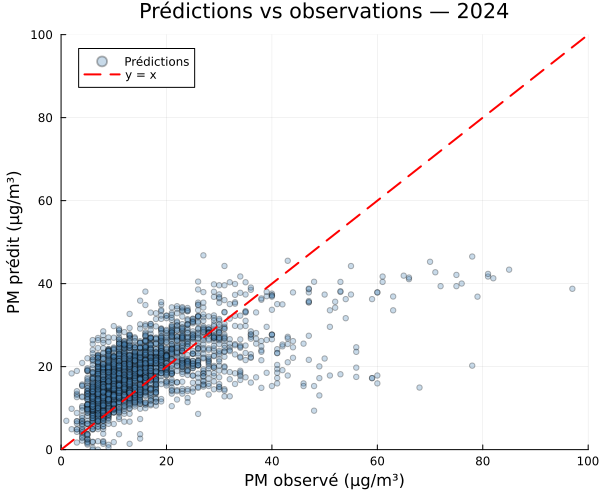

In [40]:
pm_max_plot = 100
Plots.scatter(actual_2024, preds_2024,
    alpha=0.3, markersize=3, color=:steelblue, label="Prédictions",
    xlabel="PM observé (μg/m³)", ylabel="PM prédit (μg/m³)",
    title="Prédictions vs observations — 2024",
    xlims=(0, pm_max_plot), ylims=(0, pm_max_plot),
    size=(600, 500), grid=true)

Plots.plot!([0, pm_max_plot], [0, pm_max_plot],
    color=:red, linewidth=2, linestyle=:dash, label="y = x")

Le graphique confirme ce qu'on attendait sur les predictions. 

Sur les jours normaux (PM < 30), le nuage suit globalement la diagonale même si la dispersion est importantem, le modèle capte la tendance mais pas le détail. 

Sur les pics (PM > 40), les prédictions plafonnent autour de 45 alors que les observations vont au-delà de 80. Le modèle sous-estime systématiquement les épisodes de fumée. C'est cohérent avec la nature de la régression linéaire sur une variable à queue lourde.


---
# Prédiction pour 2025

On applique au jeu de test le même traitement que sur l'entraînement : chargement, imputation, et construction des 23 variables. Pour les moyennes mobiles (NO2, pluie, visibilité, température), on recolle les derniers jours de train au début de 2025 afin d'éviter des valeurs manquantes en janvier.

## Chargement et imputation

In [41]:
test_air   = CSV.read("data/qualite-de-lair_test.csv", DataFrame)
test_meteo = CSV.read("data/meteo_test.csv", DataFrame)
test = outerjoin(test_air, test_meteo[:, 3:end], on=:Date)
test = filter(row -> !ismissing(row.stationId), test)

SO2_stations = ["Saint-Jean-Baptiste ", "Saint-Dominique", "Saint-Joseph", "Anjou"]
test = treat_so2_missing_values(test, SO2_stations)

test.mois = month.(test.Date)
sort!(test, [:stationId, :Date])
first(test, 3)

Row,stationId,nom,latitude,longitude,Élévation,Date,O3,NO2,SO2,pluie,neige,precip_tot,neige_au_sol,hum_rel_max,hum_rel_min,hum_rel_moy,pt_rosee,vitesse_vent_max,vitesse_vent_min,vitesse_vent_moy,visibilite_max,visibilite_min,visibilite_moy,pression_max,pression_min,pression_moy,temp_max,temp_min,temp_moy,mois
,Int64?,String31?,Float64?,Float64?,Int64?,Date,Int64?,Int64?,Real,Float64?,Float64?,Float64?,Int64?,Int64?,Int64?,Float64?,Float64?,Int64?,Int64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Int64
1,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2025-01-01,16,3,1,1.2,5.6,6.8,0,97,81,91.75,-0.25,26,8,16.9583,24.1,2.0,13.1417,100.12,99.2,99.515,1.9,0.4,0.958333,1
2,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2025-01-02,20,4,23,0.0,0.0,0.0,0,88,65,73.0,-5.50833,48,30,37.375,24.1,6.4,20.6958,100.09,99.2,99.7404,1.2,-3.4,-1.225,1
3,3,Saint-Jean-Baptiste,45.641,-73.4997,19,2025-01-03,21,4,20,0.0,0.4,0.4,0,78,59,64.7917,-11.4125,36,20,28.125,48.3,3.2,25.2583,100.16,99.94,100.078,-3.7,-9.5,-5.76667,1


## Construction des variables

Même chose que pour le train, sauf qu'on recolle ici les derniers jours de 2024 avant 2025 pour que les moyennes mobiles n'aient pas de trous sur les premières observations.

In [42]:
test.mois_sin          = sin.(2π .* test.mois ./ 12)
test.mois_cos          = cos.(2π .* test.mois ./ 12)
test.temp_x_mois_sin   = test.temp_moy .* test.mois_sin
test.temp_x_mois_cos   = test.temp_moy .* test.mois_cos
test.vent_x_visibilite = test.vitesse_vent_moy .* test.visibilite_moy

test_date_min = minimum(test.Date)

function plug_train_tail(test_df, train_src, cols, roll_specs, out_cols; tail_days=14)
    tail = combine(groupby(sort(train_src, [:stationId, :Date]), :stationId)) do sdf
        last(sdf, min(tail_days, nrow(sdf)))
    end
    tail_slim = select(tail, cols)
    input     = select(test_df, cols)
    comb      = vcat(tail_slim, input)
    sort!(comb, [:stationId, :Date])
    transform!(groupby(comb, :stationId), roll_specs...)
    feats = filter(row -> row.Date >= test_date_min, comb)
    select!(feats, vcat([:stationId, :Date], out_cols))
    leftjoin(test_df, feats, on=[:stationId, :Date])
end

test = plug_train_tail(test, train,
    [:stationId, :Date, :NO2, :pluie],
    [:NO2   => (x -> roll_mean(x, 3))    => :NO2_roll3,
     :pluie => jours_sans_pluie_vec      => :jours_sans_pluie,
     :pluie => (x -> roll_sum(x, 14, 7)) => :pluie_cum14],
    [:NO2_roll3, :jours_sans_pluie, :pluie_cum14])

test = plug_train_tail(test, train,
    [:stationId, :Date, :visibilite_min, :temp_max, :temp_min, :vitesse_vent_min],
    [:visibilite_min   => (x -> roll_mean(x, 3)) => :visibilite_min_roll3,
     :temp_max         => (x -> roll_mean(x, 7)) => :temp_max_roll7,
     :temp_min         => (x -> roll_mean(x, 3)) => :temp_min_roll3,
     :vitesse_vent_min => (x -> roll_mean(x, 3)) => :vent_min_roll3],
    [:visibilite_min_roll3, :temp_max_roll7, :temp_min_roll3, :vent_min_roll3])

for col in [:NO2_roll3, :vitesse_vent_moy, :visibilite_moy, :hum_rel_moy, :temp_moy,
            :visibilite_min_roll3, :temp_max_roll7, :temp_min_roll3, :vent_min_roll3,
            :pluie_cum14]
    med = median(skipmissing(train[:, col]))
    test[!, col] = Float64.(coalesce.(test[:, col], med))
end
test.jours_sans_pluie = Int.(coalesce.(test.jours_sans_pluie, 0))

test.is_fire_season  = in.(test.mois, Ref([5, 6, 7, 8, 9]))
test.is_winter       = in.(test.mois, Ref([12, 1, 2]))
test.deficit_pluie14 = Int.(test.pluie_cum14 .< Q25_PLUIE14)

test.fire_tmax_inter   = ifelse.(test.is_fire_season, test.temp_max_roll7,       0.0)
test.fire_vis_inter    = ifelse.(test.is_fire_season, test.visibilite_min_roll3, 0.0)
test.winter_tmin_inter = ifelse.(test.is_winter,      test.temp_min_roll3,       0.0)
test.winter_vent_inter = ifelse.(test.is_winter,      test.vent_min_roll3,       0.0)

println("Variables construites sur test — $(nrow(test)) lignes")

Variables construites sur test — 2555 lignes


## Prédictions 2025

In [43]:
predictions = predict(model, test)

2555-element Vector{Union{Missing, Float64}}:
 21.833483308025723
  2.868033810548435
  3.233116885313601
  9.00348267390527
 13.337808119860014
 16.496982698595684
 17.12090723534865
 12.109395488551332
 10.398097891016223
 12.288632355845726
 35.30929837655248
 22.530796623714494
 44.02529147804277
  ⋮
 10.926455594703754
  7.65861815302903
 18.03731151926013
 25.726197498785996
 28.565933700397757
 24.689312645007828
 16.167675419285192
 21.754223685537475
 28.777225325869725
 25.883299134390523
  7.097134289603427
 13.78172295068517

## Fichier de soumission

Le fichier contient une colonne `ID` (date, station) et la prédiction `PM`.

In [44]:
function createID(date::Vector{<:Date}, station::Vector{<:Any})
    [(date[i], station[i]) for i in 1:length(date)]
end

createID (generic function with 1 method)

In [45]:
benchmarkID = createID(test.Date, test.stationId)
benchmark_predictions = DataFrame(ID=benchmarkID, PM=predictions)
first(benchmark_predictions, 10)

Row,ID,PM
,Tuple…,Float64?
1,"(Date(""2025-01-01""), 3)",21.8335
2,"(Date(""2025-01-02""), 3)",2.86803
3,"(Date(""2025-01-03""), 3)",3.23312
4,"(Date(""2025-01-04""), 3)",9.00348
5,"(Date(""2025-01-05""), 3)",13.3378
6,"(Date(""2025-01-06""), 3)",16.497
7,"(Date(""2025-01-07""), 3)",17.1209
8,"(Date(""2025-01-08""), 3)",12.1094
9,"(Date(""2025-01-09""), 3)",10.3981


In [46]:
CSV.write("benchmark_predictions.csv", benchmark_predictions)

"benchmark_predictions.csv"

---
# Bilan

### Pistes avortées

Avant de choisir nolag, on a testé quatre approches différentes pour essayer de faire mieux. Aucune n'a donné un gain suffisant pour passer devant nolag.

**Les quatre approches principales, évaluées sur 2024 et 2023 (année de feux)**

| Approche | Idée | RMSE 2024 | RMSE 2023 |
|---|---|---|---|
| A) Plus de poids aux années récentes | La pollution de fond diminue avec le temps | 9.43 | 25.33 |
| B) Un modèle par station | Chaque station aurait sa propre dynamique | 10.26 | — |
| C) Séparer jours normaux et jours de fumée | Le PM suit deux régimes | 9.21 | 24.27 |
| D) Sélection de variables (VIF + AIC) | Ne garder que les variables vraiment utiles | 9.87 | 24.76 |

L'approche B découpe trop les données (environ 3500 obs par station) et donne des prédictions instables (pic prédit à 80 μg/m³), ce qui confirme que le phénomène est régional plutôt que local. 

L'approche C est la meilleure sur 2023 (RMSE fumée 72.2 contre 75.9 pour A), mais on ne l'a pas soumise parce que nolag gardait la meilleure place au classement Kaggle.

### Conclusion

On garde nolag comme soumission principale. Son score Kaggle de 18.25 tient parce qu'il s'appuie sur des variables physiques stables (vent, visibilité, NO2, saison) au lieu de la mémoire du PM, ce qui évite les erreurs qui s'accumulent d'un jour sur l'autre.

### Améliorations

Quelques pistes qui nous auraient probablement fait gagner plusieurs points de RMSE :

- Ajouter des données extérieures comme les feux détectés par satellite (NASA FIRMS), les trajectoires des panaches (HYSPLIT), ou les PM des villes voisines (Toronto, Ottawa, Albany), pour anticiper les épisodes de fumée qui arrivent de loin.

- Sur-pondérer directement les jours où PM dépasse 35 plutôt que d'ajuster les poids par année.

- Utiliser un modèle de forêt aléatoire ou un gradient boosting pour capturer les non-linéarités et les interactions complexes.